In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA




In [ ]:
def apply_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i in range(n_components):
        print(f"PC{i+1} Explained Variance: {explained_variance_ratio[i]*100:.2f}%")

    print(f"Total Variance Explained: {cumulative_variance[-1]*100:.2f}%")
    print("-" * 50)

    return X_pca, explained_variance_ratio, cumulative_variance



In [ ]:
def plot_pca_2d(X_pca, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=label)

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()



In [ ]:

def plot_scree(explained_variance_ratio, cumulative_variance):
    components = np.arange(1, len(explained_variance_ratio) + 1)

    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(True)
    plt.show()



In [ ]:

def compare_original_vs_pca(X, X_pca, y, feature_names):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Original Data")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Transformed Data")
    plt.grid(True)

    plt.tight_layout()
    plt.show()




Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
Total Variance Explained: 95.81%
--------------------------------------------------


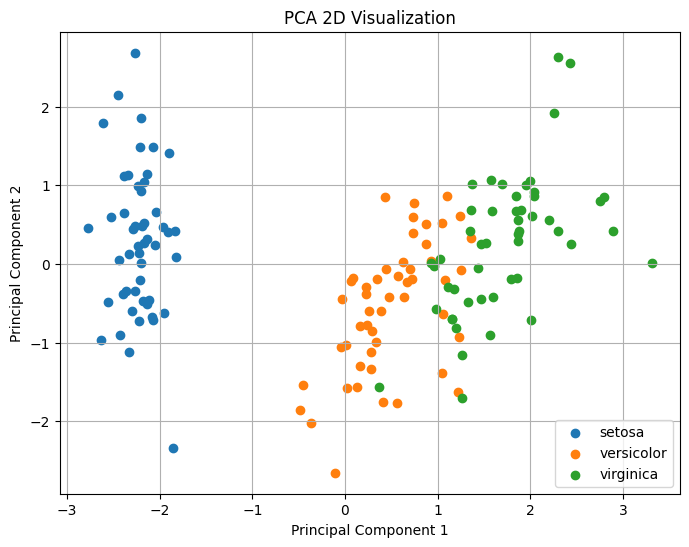

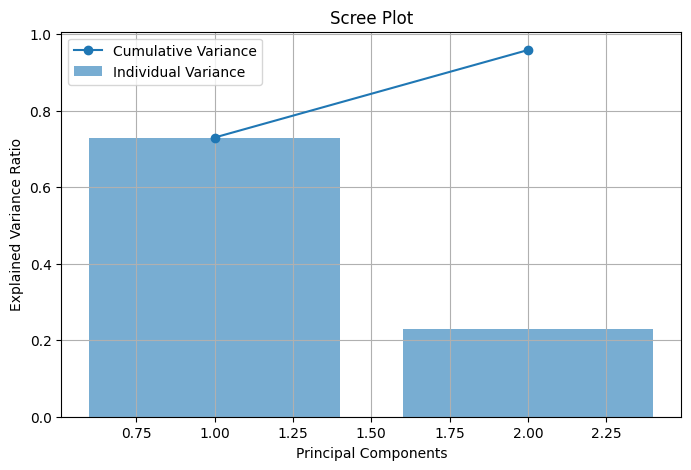

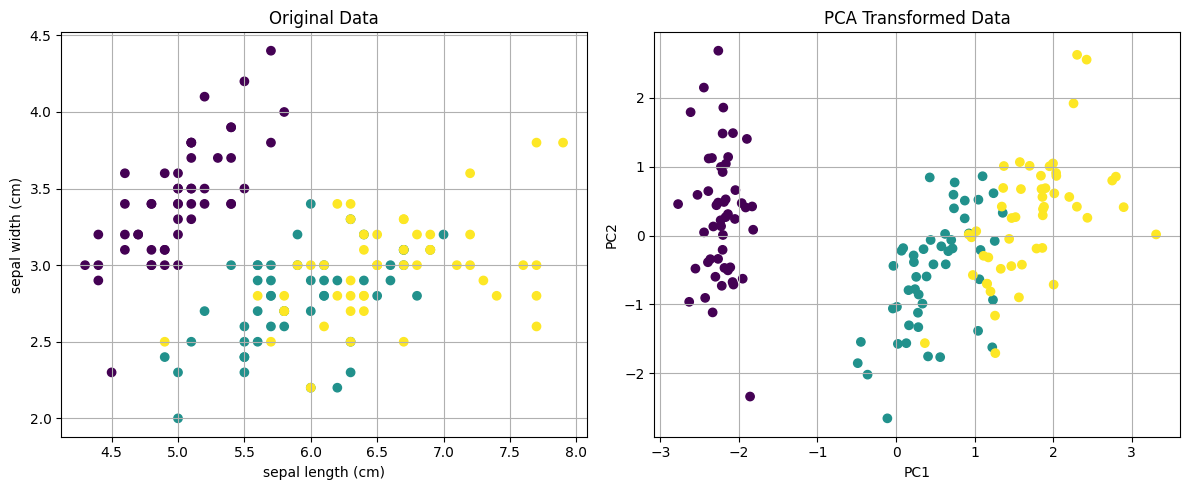

In [ ]:

def main():
    X, y, feature_names, target_names = load_dataset('iris')

    X_standardized, X_normalized = preprocess_data(X)

    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)

    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

if __name__ == "__main__":
    main()

In [ ]:
def load_dataset(name):
    if name == 'iris':
        data = load_iris()
    elif name == 'wine':
        data = load_wine()
    else:
        raise ValueError("Dataset not supported. Choose 'iris' or 'wine'.")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Loaded {name.capitalize()} dataset")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)

    return X, y, feature_names, target_names

def preprocess_data(X):
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    min_max_scaler = MinMaxScaler()
    X_normalized = min_max_scaler.fit_transform(X)

    print("Preprocessing Completed")
    print(f"Standardized data mean: {np.mean(X_standardized):.2f}")
    print(f"Standardized data std: {np.std(X_standardized):.2f}")
    print(f"Normalized data range: [{np.min(X_normalized):.2f}, {np.max(X_normalized):.2f}]")
    print("-" * 50)

    return X_standardized, X_normalized

print("Functions 'load_dataset' and 'preprocess_data' defined.")

Functions 'load_dataset' and 'preprocess_data' defined.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA


**Reasoning**:
The next step is to define the `plot_pca_3d` function as specified in the instructions, which will handle the 3D visualization of the PCA results.



In [ ]:
def plot_pca_3d(X_pca_3d, y, target_names):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, label in enumerate(target_names):
        ax.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2], label=label)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA 3D Visualization')
    ax.legend()
    ax.grid(True)
    plt.show()


In [ ]:
def main():
    X, y, feature_names, target_names = load_dataset('iris')

    X_standardized, X_normalized = preprocess_data(X)

    # Apply PCA for 2 components (existing)
    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)

    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

    # Apply PCA for 3 components (new)
    X_pca_3d, explained_variance_ratio_3d, cumulative_variance_3d = apply_pca(X_standardized, n_components=3)

    # Plot 3D PCA (new)
    plot_pca_3d(X_pca_3d, y, target_names)

    # Optionally, plot scree for 3 components if needed, or remove if 2-component scree is sufficient
    # plot_scree(explained_variance_ratio_3d, cumulative_variance_3d)

if __name__ == "__main__":
    main()

Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------


NameError: name 'apply_pca' is not defined

Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
Total Variance Explained: 95.81%
--------------------------------------------------


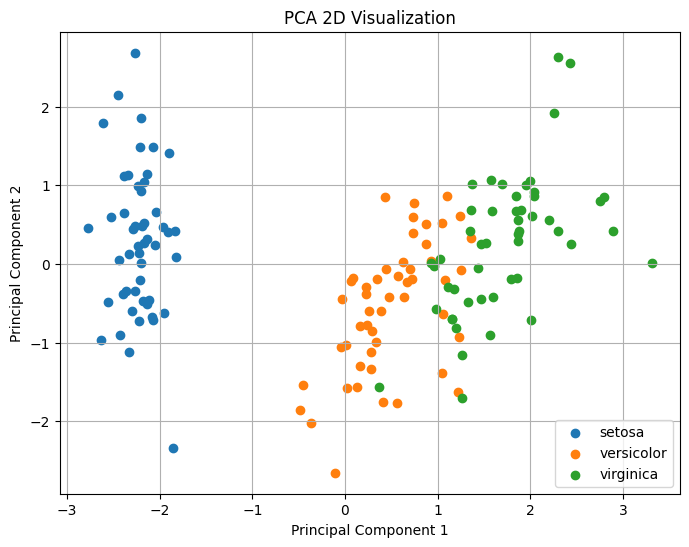

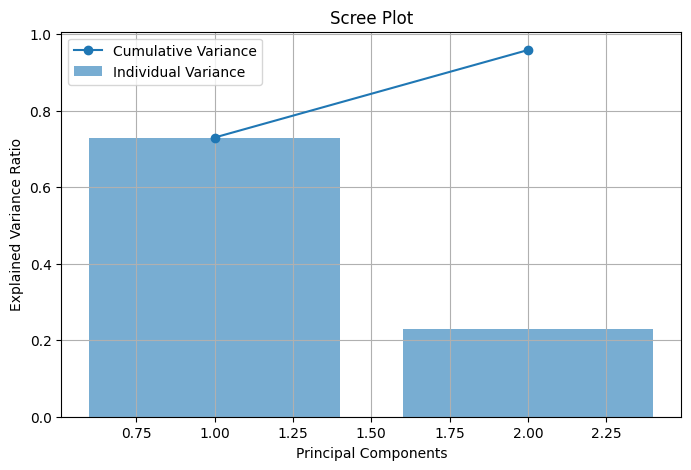

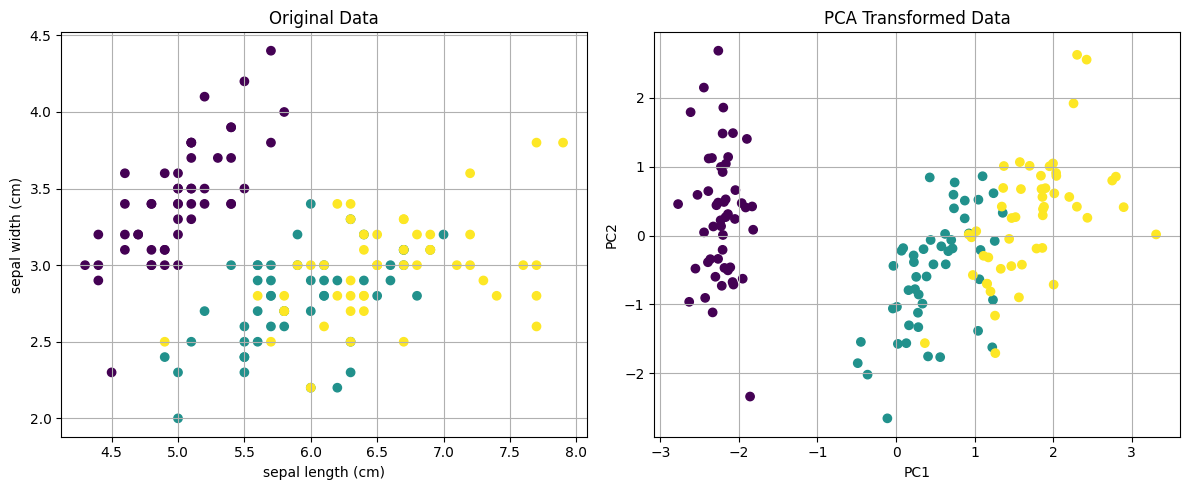

PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
Total Variance Explained: 99.48%
--------------------------------------------------


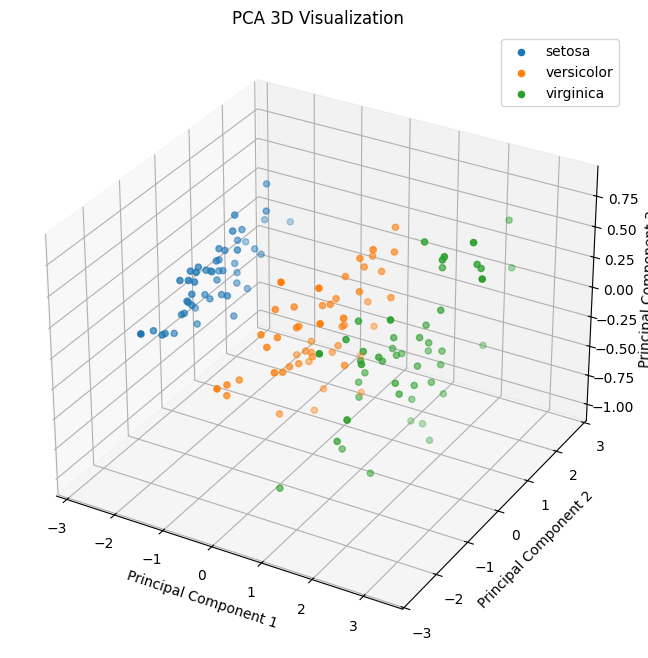


Running PCA for all 4 components...
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
PC4 Explained Variance: 0.52%
Total Variance Explained: 100.00%
--------------------------------------------------
Displaying Scree Plot for all components...


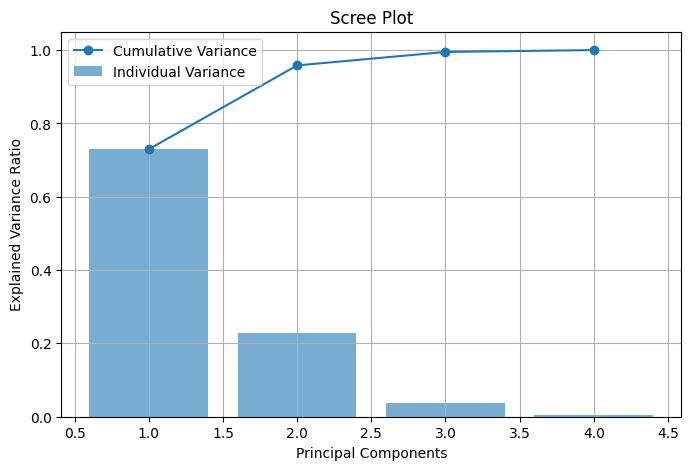


Applying LDA for 2 components...
LDA Results:
Number of components: 2
--------------------------------------------------
Displaying LDA 2D Visualization...


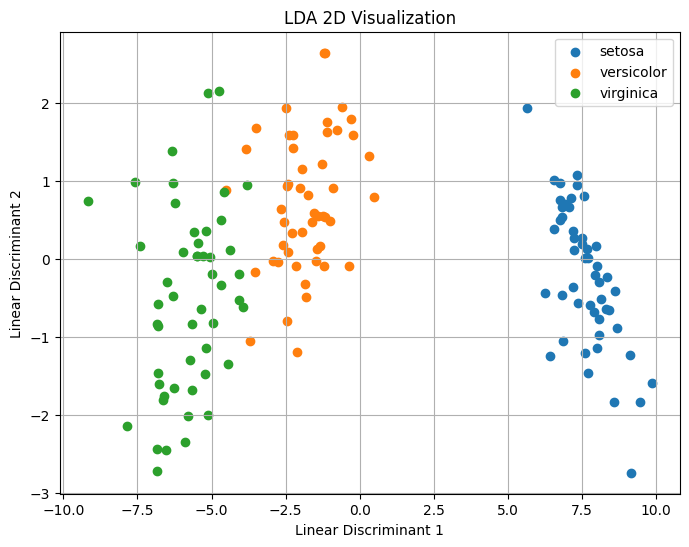


Applying Kernel PCA with RBF kernel...
Kernel PCA Results (Kernel: rbf, Components: 2):
--------------------------------------------------
Displaying Kernel PCA 2D Visualization with RBF kernel...


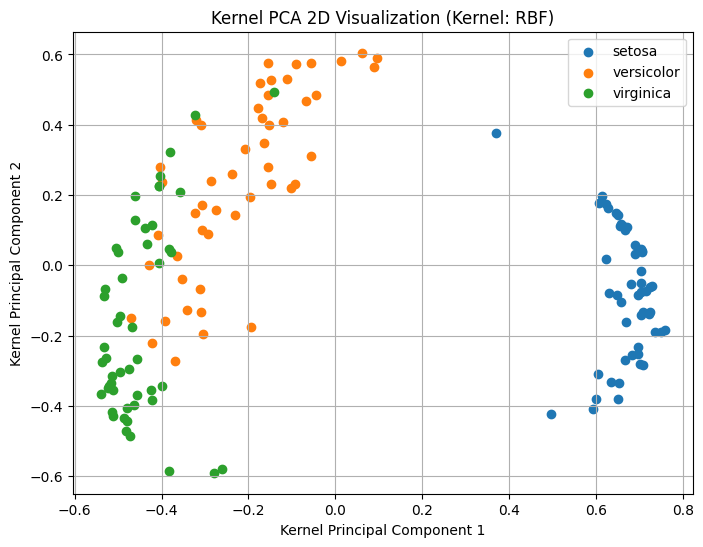


Applying Kernel PCA with Polynomial kernel...
Kernel PCA Results (Kernel: poly, Components: 2):
--------------------------------------------------
Displaying Kernel PCA 2D Visualization with Polynomial kernel...


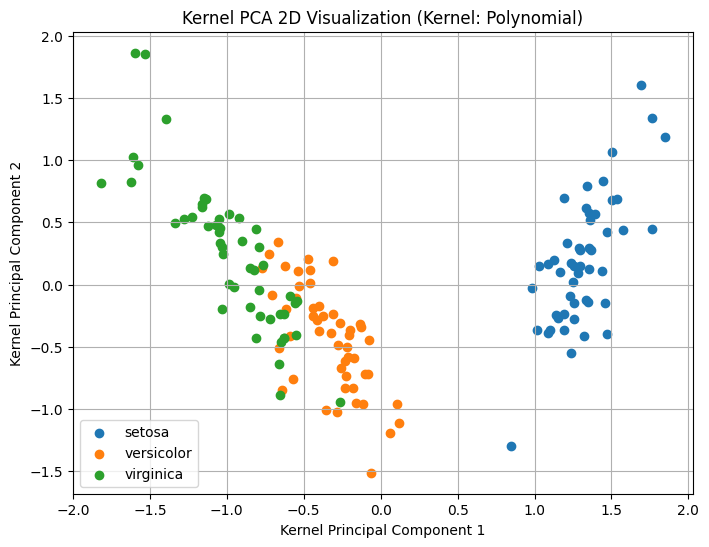


Reconstructing data with PCA (2 components) and calculating MSE...
Mean Squared Error (MSE) between original standardized data and 2-component PCA reconstructed data: 0.0419
--------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import mean_squared_error

def load_dataset(name):
    if name == 'iris':
        data = load_iris()
    elif name == 'wine':
        data = load_wine()
    else:
        raise ValueError("Dataset not supported. Choose 'iris' or 'wine'.")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Loaded {name.capitalize()} dataset")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)
    return X, y, feature_names, target_names

def preprocess_data(X):
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)
    min_max_scaler = MinMaxScaler()
    X_normalized = min_max_scaler.fit_transform(X)

    print("Preprocessing Completed")
    print(f"Standardized data mean: {np.mean(X_standardized):.2f}")
    print(f"Standardized data std: {np.std(X_standardized):.2f}")
    print(f"Normalized data range: [{np.min(X_normalized):.2f}, {np.max(X_normalized):.2f}]")
    print("-" * 50)
    return X_standardized, X_normalized

def apply_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i in range(n_components):
        print(f"PC{i+1} Explained Variance: {explained_variance_ratio[i]*100:.2f}%")
    print(f"Total Variance Explained: {cumulative_variance[-1]*100:.2f}%")
    print("-" * 50)
    return X_pca, explained_variance_ratio, cumulative_variance

def apply_lda(X, y, n_components=2):
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda = lda.fit_transform(X, y)

    print("LDA Results:")
    print(f"Number of components: {n_components}")
    print("-" * 50)
    return X_lda

def apply_kernel_pca(X, n_components=2, kernel='rbf', gamma=None, degree=3, coef0=1):
    kpca_params = {
        'n_components': n_components,
        'kernel': kernel,
        'fit_inverse_transform': True
    }
    if kernel == 'rbf':
        if gamma is not None:
            kpca_params['gamma'] = gamma
    elif kernel == 'poly':
        kpca_params['degree'] = degree
        kpca_params['coef0'] = coef0
        if gamma is not None:
            kpca_params['gamma'] = gamma
    elif kernel == 'sigmoid':
        if gamma is not None:
            kpca_params['gamma'] = gamma
        kpca_params['coef0'] = coef0

    kpca = KernelPCA(**kpca_params)
    X_kpca = kpca.fit_transform(X)

    print(f"Kernel PCA Results (Kernel: {kernel}, Components: {n_components}):")
    print("-" * 50)
    return X_kpca

def reconstruct_and_calculate_mse(X_original, X_standardized, n_components=2):
    print(f"\nReconstructing data with PCA ({n_components} components) and calculating MSE...")
    pca_reconstruct = PCA(n_components=n_components)
    X_pca_reconstruction = pca_reconstruct.fit_transform(X_standardized)
    X_reconstructed = pca_reconstruct.inverse_transform(X_pca_reconstruction)

    mse = mean_squared_error(X_standardized, X_reconstructed)
    print(f"Mean Squared Error (MSE) between original standardized data and {n_components}-component PCA reconstructed data: {mse:.4f}")
    print("-" * 50)

def plot_pca_2d(X_pca, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=label)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_pca_3d(X_pca_3d, y, target_names):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    for i, label in enumerate(target_names):
        ax.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2], label=label)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA 3D Visualization')
    ax.legend()
    ax.grid(True)
    plt.show()

def plot_lda_2d(X_lda, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=label)
    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("LDA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_kernel_pca_2d(X_kpca, y, target_names, kernel_name):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_kpca[y == i, 0], X_kpca[y == i, 1], label=label)
    plt.xlabel("Kernel Principal Component 1")
    plt.ylabel("Kernel Principal Component 2")
    plt.title(f"Kernel PCA 2D Visualization (Kernel: {kernel_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_scree(explained_variance_ratio, cumulative_variance):
    components = np.arange(1, len(explained_variance_ratio) + 1)
    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

def compare_original_vs_pca(X, X_pca, y, feature_names):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Original Data")
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Transformed Data")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    X, y, feature_names, target_names = load_dataset('iris')
    X_standardized, X_normalized = preprocess_data(X)

    # PCA with 2 components
    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)
    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

    # PCA with 3 components
    X_pca_3d, explained_variance_ratio_3d, cumulative_variance_3d = apply_pca(X_standardized, n_components=3)
    plot_pca_3d(X_pca_3d, y, target_names)

    # PCA for all possible components and Scree Plot
    total_features = X_standardized.shape[1]
    print(f"\nRunning PCA for all {total_features} components...")
    X_pca_full, explained_variance_ratio_full, cumulative_variance_full = apply_pca(X_standardized, n_components=total_features)
    print("Displaying Scree Plot for all components...")
    plot_scree(explained_variance_ratio_full, cumulative_variance_full)

    # LDA with 2 components
    print("\nApplying LDA for 2 components...")
    n_components_lda = min(len(np.unique(y)) - 1, X_standardized.shape[1])
    X_lda = apply_lda(X_standardized, y, n_components=n_components_lda)
    print("Displaying LDA 2D Visualization...")
    plot_lda_2d(X_lda, y, target_names)

    # Kernel PCA with RBF kernel
    print("\nApplying Kernel PCA with RBF kernel...")
    X_kpca_rbf = apply_kernel_pca(X_standardized, n_components=2, kernel='rbf', gamma=0.1)
    print("Displaying Kernel PCA 2D Visualization with RBF kernel...")
    plot_kernel_pca_2d(X_kpca_rbf, y, target_names, 'RBF')

    # Kernel PCA with Polynomial kernel
    print("\nApplying Kernel PCA with Polynomial kernel...")
    X_kpca_poly = apply_kernel_pca(X_standardized, n_components=2, kernel='poly', degree=3, gamma=0.1)
    print("Displaying Kernel PCA 2D Visualization with Polynomial kernel...")
    plot_kernel_pca_2d(X_kpca_poly, y, target_names, 'Polynomial')

    # Reconstruct data and calculate MSE
    reconstruct_and_calculate_mse(X, X_standardized, n_components=2)

if __name__ == "__main__":
    main()

Loaded Iris dataset. Shape: (150, 4)
Data standardized.

--- Running PCA Analysis ---
2D PCA: PC1 variance: 72.96%, PC2 variance: 22.85%
2D PCA Total Explained Variance: 95.81%


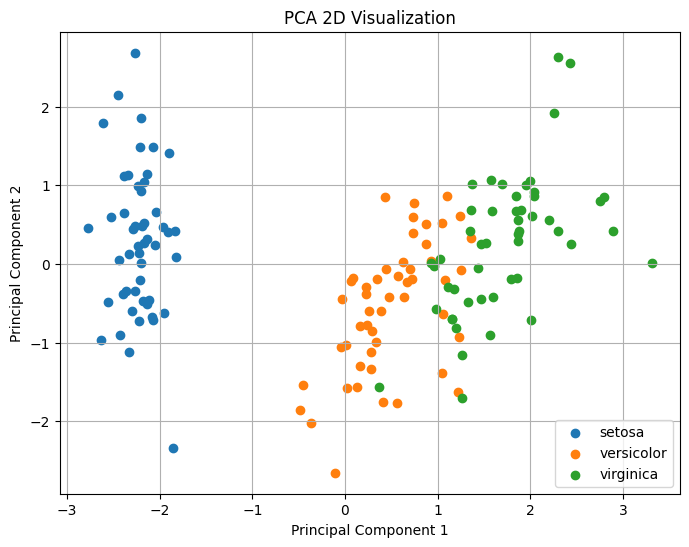

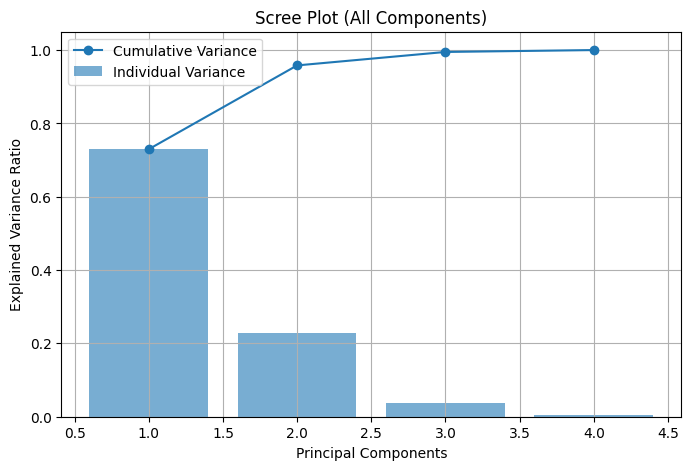


--- Running LDA Analysis ---
LDA applied with 2 components.


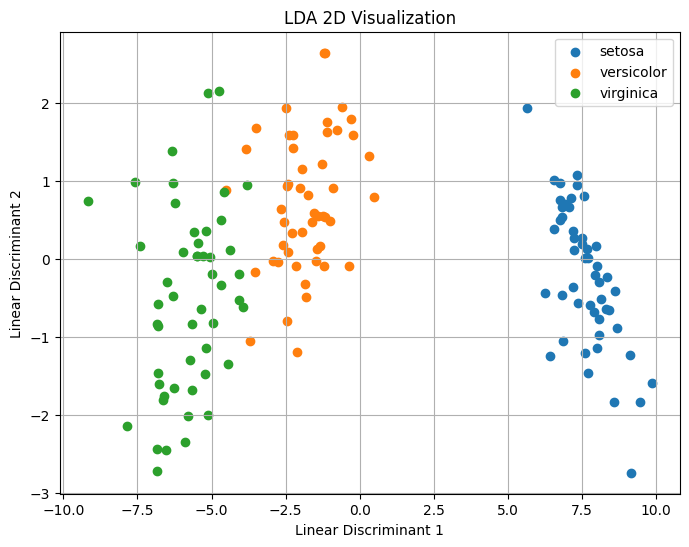


--- Running Kernel PCA Analysis ---
Kernel PCA (RBF kernel) applied.


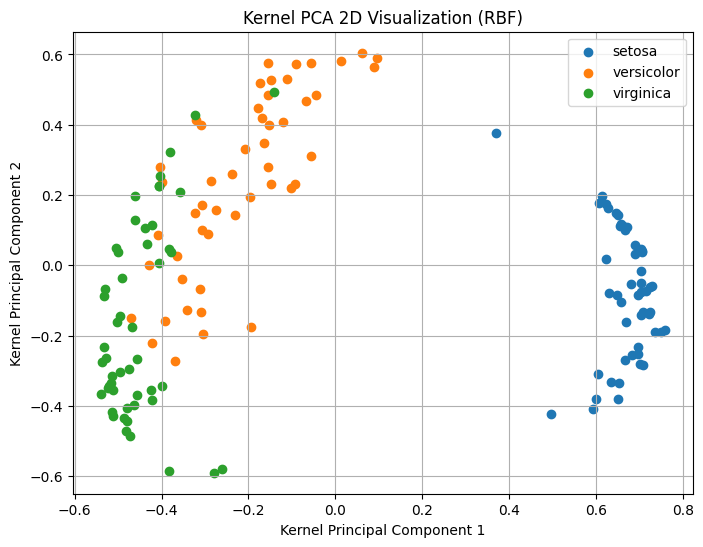


--- Calculating Reconstruction Error ---
Reconstruction MSE with 2 PCA components: 0.0419


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import mean_squared_error

def load_and_preprocess_data(name='iris'):
    data = load_iris() if name == 'iris' else load_wine()
    X, y, feature_names, target_names = data.data, data.target, data.feature_names, data.target_names
    print(f"Loaded {name.capitalize()} dataset. Shape: {X.shape}")
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)
    print("Data standardized.")
    return X, y, feature_names, target_names, X_standardized

def run_pca_analysis(X_standardized, y, target_names):
    print("\n--- Running PCA Analysis ---")
    # 2D PCA
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_standardized)
    print(f"2D PCA: PC1 variance: {pca_2d.explained_variance_ratio_[0]*100:.2f}%, PC2 variance: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
    print(f"2D PCA Total Explained Variance: {np.sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca_2d[y == i, 0], X_pca_2d[y == i, 1], label=label)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Scree Plot (all components)
    pca_full = PCA(n_components=X_standardized.shape[1])
    pca_full.fit(X_standardized)
    explained_variance_ratio_full = pca_full.explained_variance_ratio_
    cumulative_variance_full = np.cumsum(explained_variance_ratio_full)

    plt.figure(figsize=(8, 5))
    components = np.arange(1, len(explained_variance_ratio_full) + 1)
    plt.bar(components, explained_variance_ratio_full, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance_full, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot (All Components)")
    plt.legend()
    plt.grid(True)
    plt.show()

def run_lda_analysis(X_standardized, y, target_names):
    print("\n--- Running LDA Analysis ---")
    n_components_lda = min(len(np.unique(y)) - 1, X_standardized.shape[1])
    lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
    X_lda = lda.fit_transform(X_standardized, y)
    print(f"LDA applied with {n_components_lda} components.")

    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=label)
    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("LDA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def run_kernel_pca_analysis(X_standardized, y, target_names):
    print("\n--- Running Kernel PCA Analysis ---")
    # RBF Kernel
    kpca_rbf = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, fit_inverse_transform=True)
    X_kpca_rbf = kpca_rbf.fit_transform(X_standardized)
    print("Kernel PCA (RBF kernel) applied.")

    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_kpca_rbf[y == i, 0], X_kpca_rbf[y == i, 1], label=label)
    plt.xlabel("Kernel Principal Component 1")
    plt.ylabel("Kernel Principal Component 2")
    plt.title("Kernel PCA 2D Visualization (RBF)")
    plt.legend()
    plt.grid(True)
    plt.show()

def calculate_reconstruction_error(X_standardized, n_components=2):
    print("\n--- Calculating Reconstruction Error ---")
    pca_reconstruct = PCA(n_components=n_components)
    X_pca_reduced = pca_reconstruct.fit_transform(X_standardized)
    X_reconstructed = pca_reconstruct.inverse_transform(X_pca_reduced)
    mse = mean_squared_error(X_standardized, X_reconstructed)
    print(f"Reconstruction MSE with {n_components} PCA components: {mse:.4f}")

def main():
    X_original, y, feature_names, target_names, X_standardized = load_and_preprocess_data()

    run_pca_analysis(X_standardized, y, target_names)
    run_lda_analysis(X_standardized, y, target_names)
    run_kernel_pca_analysis(X_standardized, y, target_names)
    calculate_reconstruction_error(X_standardized)

if __name__ == "__main__":
    main()

## Analyze Variance Retention

### Subtask:
Run PCA for all possible principal components and visualize the explained variance using a scree plot.


**Reasoning**:
To analyze variance retention, I need to modify the `main` function to perform PCA with the maximum possible number of principal components (equal to the number of features) and then visualize the explained variance using a scree plot. I will put all the function definitions and the modified `main` function in a single code block to ensure proper execution order and avoid `NameError`.



Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
Total Variance Explained: 95.81%
--------------------------------------------------


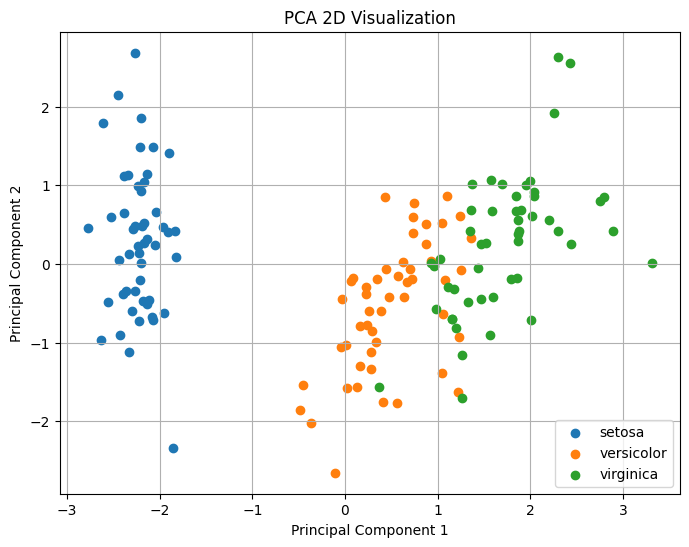

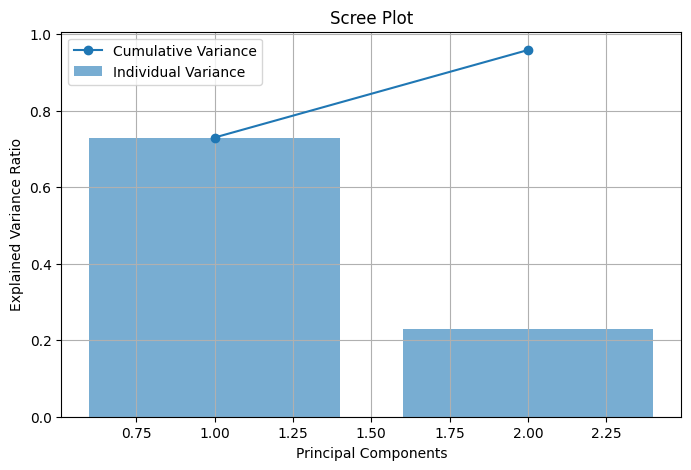

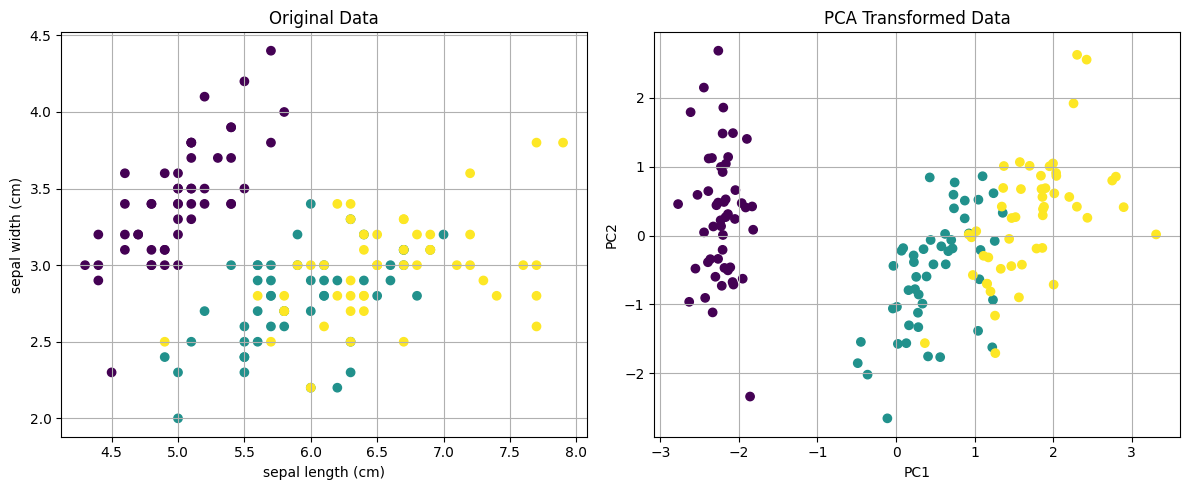

PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
Total Variance Explained: 99.48%
--------------------------------------------------


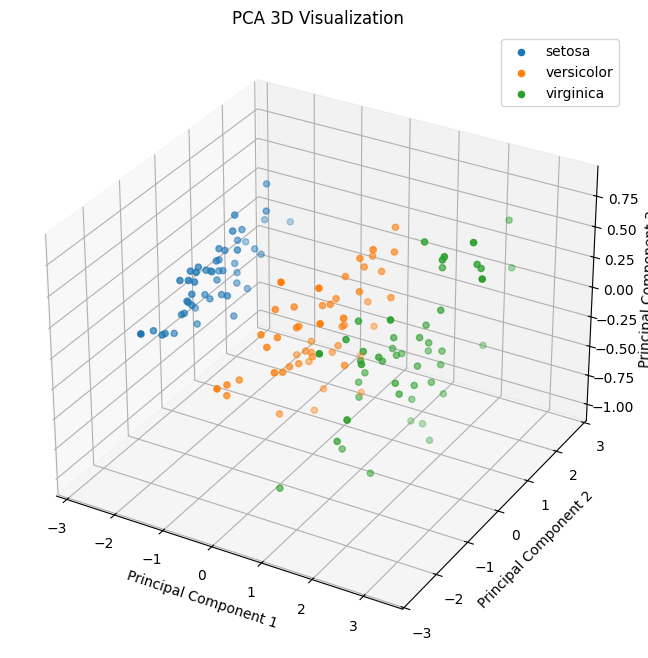


Running PCA for all 4 components...
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
PC4 Explained Variance: 0.52%
Total Variance Explained: 100.00%
--------------------------------------------------
Displaying Scree Plot for all components...


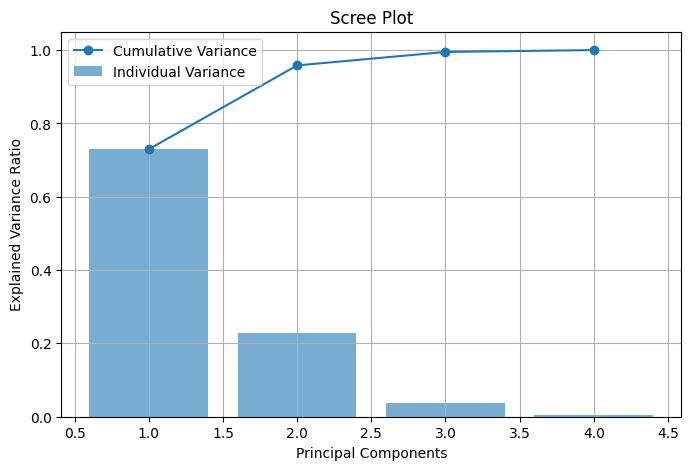

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

def apply_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i in range(n_components):
        print(f"PC{i+1} Explained Variance: {explained_variance_ratio[i]*100:.2f}%")

    print(f"Total Variance Explained: {cumulative_variance[-1]*100:.2f}%")
    print("-" * 50)

    return X_pca, explained_variance_ratio, cumulative_variance

def plot_pca_2d(X_pca, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=label)

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_scree(explained_variance_ratio, cumulative_variance):
    components = np.arange(1, len(explained_variance_ratio) + 1)

    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

def compare_original_vs_pca(X, X_pca, y, feature_names):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Original Data")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Transformed Data")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def load_dataset(name):
    if name == 'iris':
        data = load_iris()
    elif name == 'wine':
        data = load_wine()
    else:
        raise ValueError("Dataset not supported. Choose 'iris' or 'wine'.")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Loaded {name.capitalize()} dataset")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)

    return X, y, feature_names, target_names

def preprocess_data(X):
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    min_max_scaler = MinMaxScaler()
    X_normalized = min_max_scaler.fit_transform(X)

    print("Preprocessing Completed")
    print(f"Standardized data mean: {np.mean(X_standardized):.2f}")
    print(f"Standardized data std: {np.std(X_standardized):.2f}")
    print(f"Normalized data range: [{np.min(X_normalized):.2f}, {np.max(X_normalized):.2f}]")
    print("-" * 50)

    return X_standardized, X_normalized

def plot_pca_3d(X_pca_3d, y, target_names):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, label in enumerate(target_names):
        ax.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2], label=label)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA 3D Visualization')
    ax.legend()
    ax.grid(True)
    plt.show()

def main():
    X, y, feature_names, target_names = load_dataset('iris')

    X_standardized, X_normalized = preprocess_data(X)

    # Apply PCA for 2 components (existing)
    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)

    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

    # Apply PCA for 3 components (existing)
    X_pca_3d, explained_variance_ratio_3d, cumulative_variance_3d = apply_pca(X_standardized, n_components=3)

    # Plot 3D PCA (existing)
    plot_pca_3d(X_pca_3d, y, target_names)

    # New: Run PCA for all possible principal components and visualize the explained variance using a scree plot.
    total_features = X_standardized.shape[1]
    print(f"\nRunning PCA for all {total_features} components...")
    X_pca_full, explained_variance_ratio_full, cumulative_variance_full = apply_pca(X_standardized, n_components=total_features)

    # Plot scree for all components
    print("Displaying Scree Plot for all components...")
    plot_scree(explained_variance_ratio_full, cumulative_variance_full)

if __name__ == "__main__":
    main()


## Implement and Compare PCA with LDA

### Subtask:
Apply Linear Discriminant Analysis (LDA) to the preprocessed data, and compare its 2D projection with the 2D PCA projection, focusing on class separation. Create a 2D scatter plot for LDA results.


**Reasoning**:
I need to import `LinearDiscriminantAnalysis`, define new functions `apply_lda` and `plot_lda_2d`, and then integrate these into the `main` function to apply LDA and visualize its 2D projection. To ensure all functions are defined before `main` is called and to avoid `NameError` issues, I will place all imports, function definitions, and the updated `main` function in a single code cell.



Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
Total Variance Explained: 95.81%
--------------------------------------------------


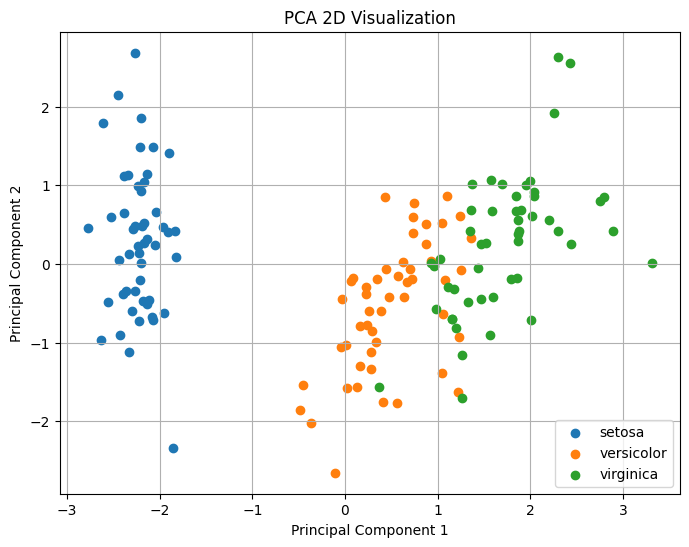

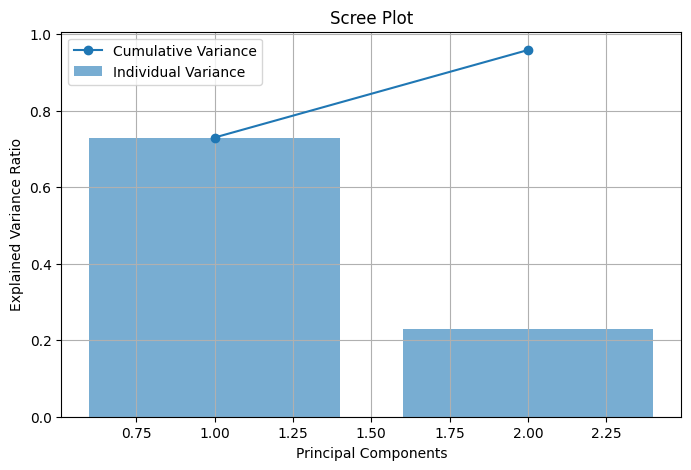

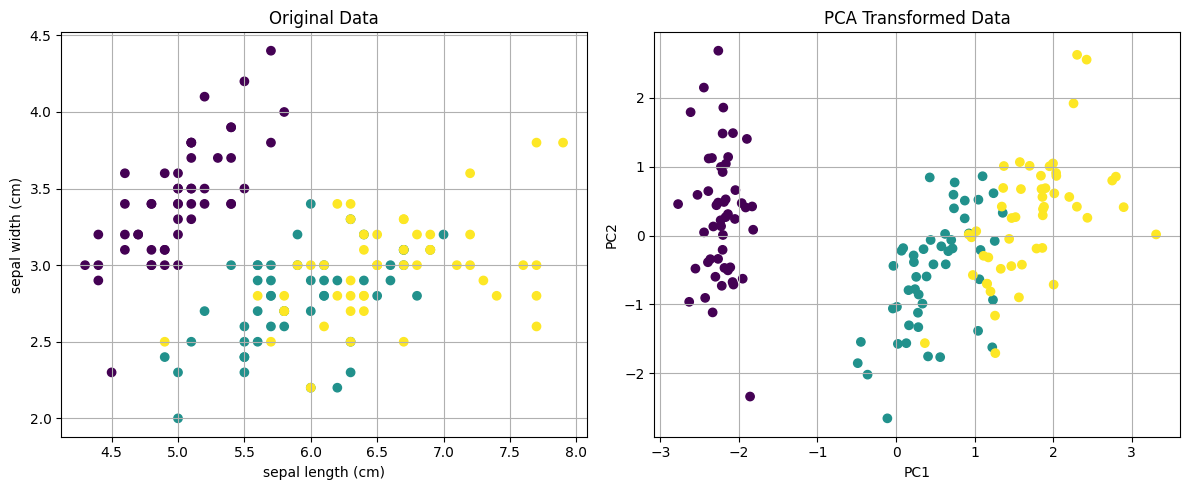

PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
Total Variance Explained: 99.48%
--------------------------------------------------


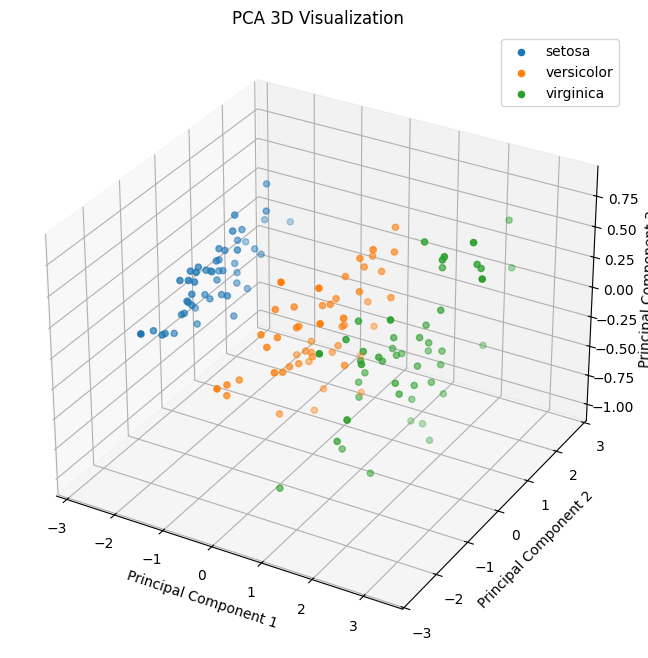


Running PCA for all 4 components...
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
PC4 Explained Variance: 0.52%
Total Variance Explained: 100.00%
--------------------------------------------------
Displaying Scree Plot for all components...


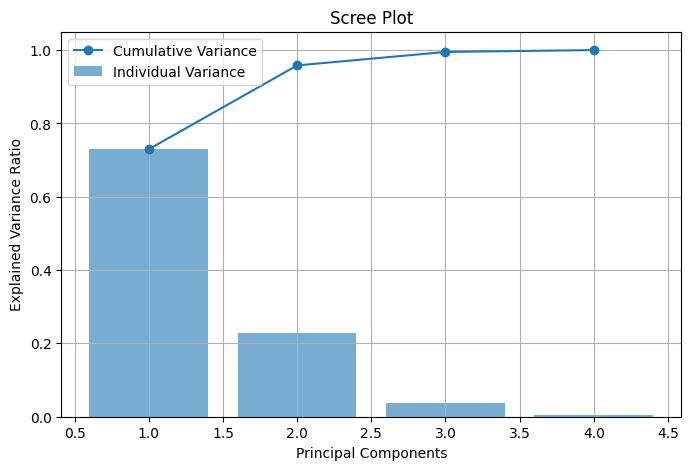


Applying LDA for 2 components...
LDA Results:
Number of components: 2
--------------------------------------------------
Displaying LDA 2D Visualization...


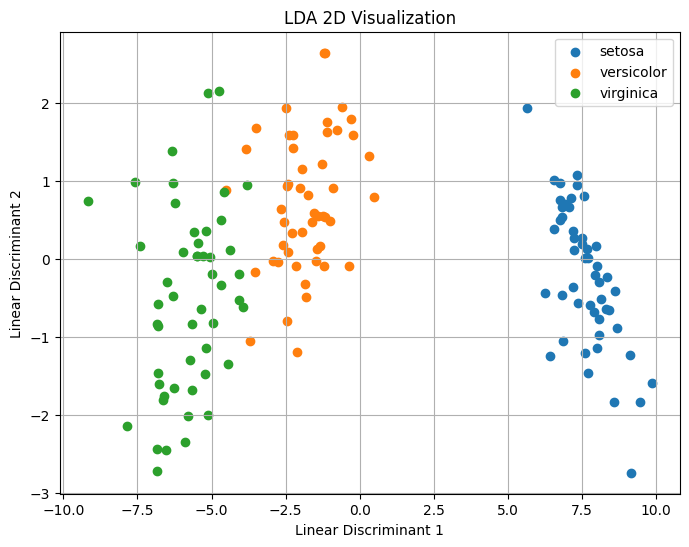

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # New import

def apply_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i in range(n_components):
        print(f"PC{i+1} Explained Variance: {explained_variance_ratio[i]*100:.2f}%")

    print(f"Total Variance Explained: {cumulative_variance[-1]*100:.2f}%")
    print("-" * 50)

    return X_pca, explained_variance_ratio, cumulative_variance

def apply_lda(X, y, n_components=2):
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda = lda.fit_transform(X, y)

    print("LDA Results:")
    print(f"Number of components: {n_components}")
    print("-" * 50)

    return X_lda

def plot_pca_2d(X_pca, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=label)

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_lda_2d(X_lda, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=label)

    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("LDA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_scree(explained_variance_ratio, cumulative_variance):
    components = np.arange(1, len(explained_variance_ratio) + 1)

    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

def compare_original_vs_pca(X, X_pca, y, feature_names):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Original Data")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Transformed Data")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def load_dataset(name):
    if name == 'iris':
        data = load_iris()
    elif name == 'wine':
        data = load_wine()
    else:
        raise ValueError("Dataset not supported. Choose 'iris' or 'wine'.")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Loaded {name.capitalize()} dataset")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)

    return X, y, feature_names, target_names

def preprocess_data(X):
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    min_max_scaler = MinMaxScaler()
    X_normalized = min_max_scaler.fit_transform(X)

    print("Preprocessing Completed")
    print(f"Standardized data mean: {np.mean(X_standardized):.2f}")
    print(f"Standardized data std: {np.std(X_standardized):.2f}")
    print(f"Normalized data range: [{np.min(X_normalized):.2f}, {np.max(X_normalized):.2f}]")
    print("-" * 50)

    return X_standardized, X_normalized

def plot_pca_3d(X_pca_3d, y, target_names):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, label in enumerate(target_names):
        ax.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2], label=label)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA 3D Visualization')
    ax.legend()
    ax.grid(True)
    plt.show()

def main():
    X, y, feature_names, target_names = load_dataset('iris')

    X_standardized, X_normalized = preprocess_data(X)

    # Apply PCA for 2 components (existing)
    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)

    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

    # Apply PCA for 3 components (existing)
    X_pca_3d, explained_variance_ratio_3d, cumulative_variance_3d = apply_pca(X_standardized, n_components=3)

    # Plot 3D PCA (existing)
    plot_pca_3d(X_pca_3d, y, target_names)

    # Run PCA for all possible principal components and visualize the explained variance using a scree plot.
    total_features = X_standardized.shape[1]
    print(f"\nRunning PCA for all {total_features} components...")
    X_pca_full, explained_variance_ratio_full, cumulative_variance_full = apply_pca(X_standardized, n_components=total_features)

    # Plot scree for all components
    print("Displaying Scree Plot for all components...")
    plot_scree(explained_variance_ratio_full, cumulative_variance_full)

    # New: Apply LDA for 2 components
    print("\nApplying LDA for 2 components...")
    # n_components for LDA should be min(n_classes - 1, n_features). For Iris (3 classes), it's 2.
    n_components_lda = min(len(np.unique(y)) - 1, X_standardized.shape[1])
    X_lda = apply_lda(X_standardized, y, n_components=n_components_lda)

    # New: Plot 2D LDA
    print("Displaying LDA 2D Visualization...")
    plot_lda_2d(X_lda, y, target_names)

if __name__ == "__main__":
    main()


## Implement Kernel PCA

### Subtask:
Apply Kernel PCA to the preprocessed data using different kernels (e.g., 'rbf', 'poly') and parameters. Visualize the 2D projection of Kernel PCA results, with a legend, to observe its non-linear separation capabilities.


**Reasoning**:
I need to implement Kernel PCA with different kernels and visualize their 2D projections. This involves adding `KernelPCA` to the imports, defining new functions `apply_kernel_pca` and `plot_kernel_pca_2d`, and integrating these into the `main` function. To ensure proper execution and avoid `NameError`, I will consolidate all code into a single block.



Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
Total Variance Explained: 95.81%
--------------------------------------------------


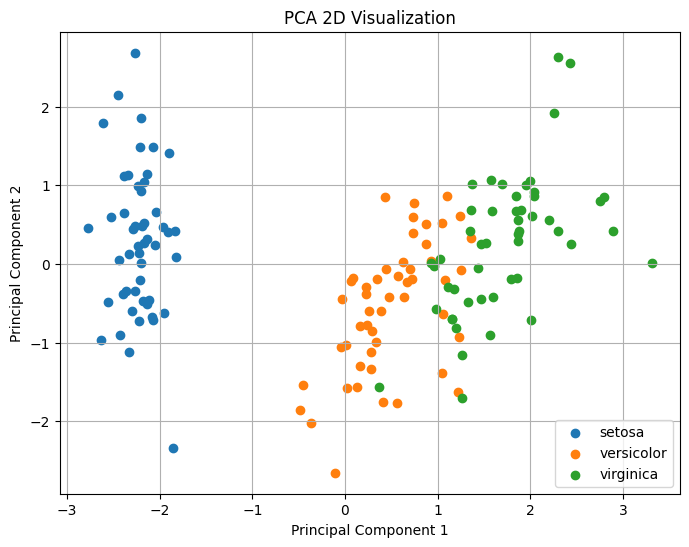

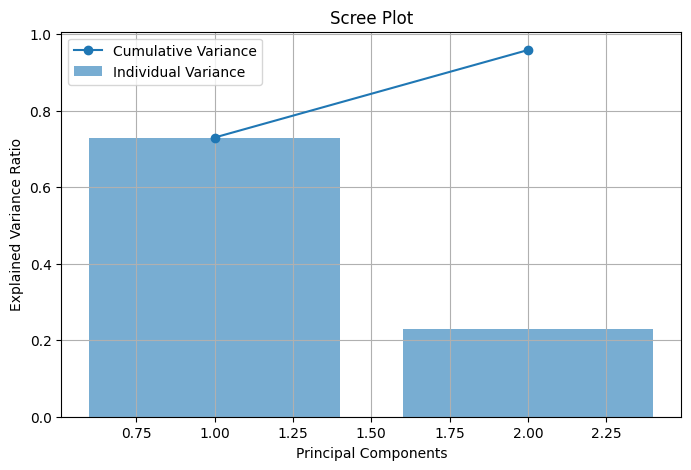

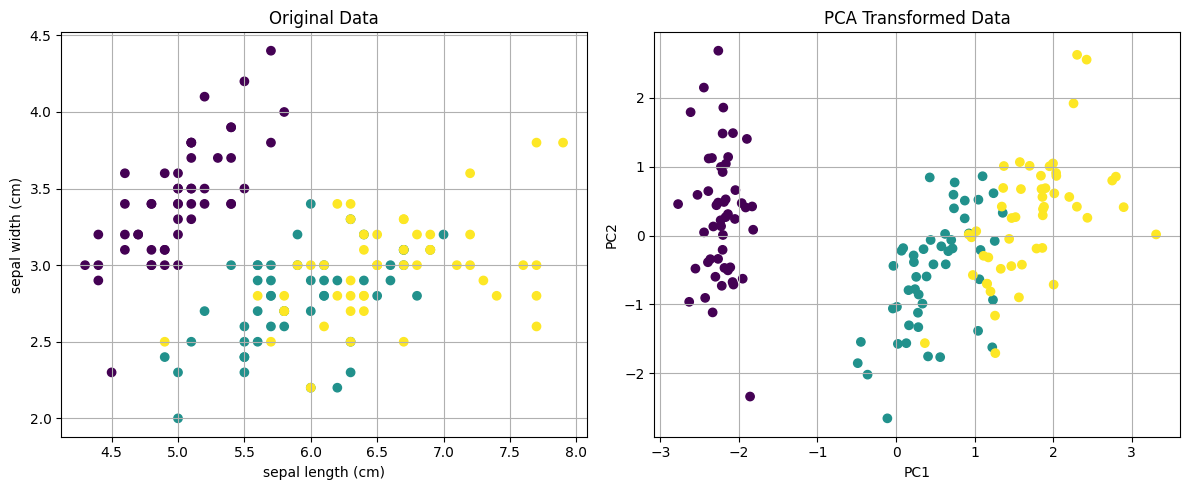

PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
Total Variance Explained: 99.48%
--------------------------------------------------


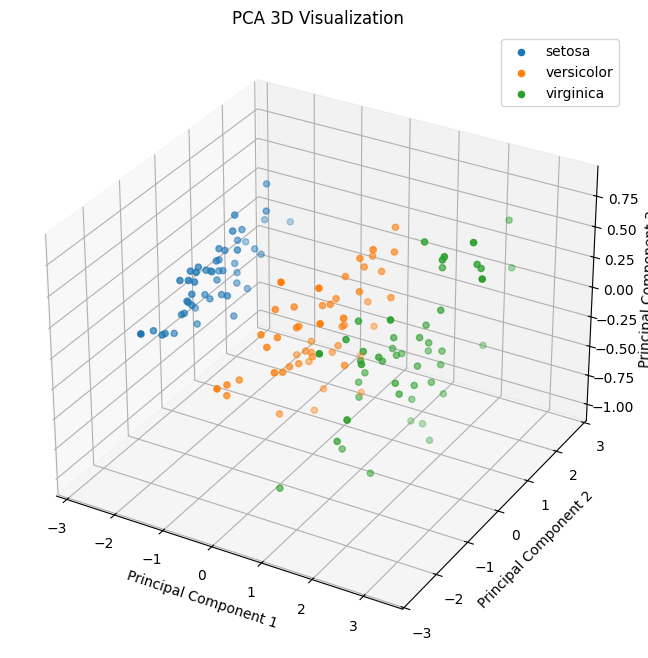


Running PCA for all 4 components...
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
PC4 Explained Variance: 0.52%
Total Variance Explained: 100.00%
--------------------------------------------------
Displaying Scree Plot for all components...


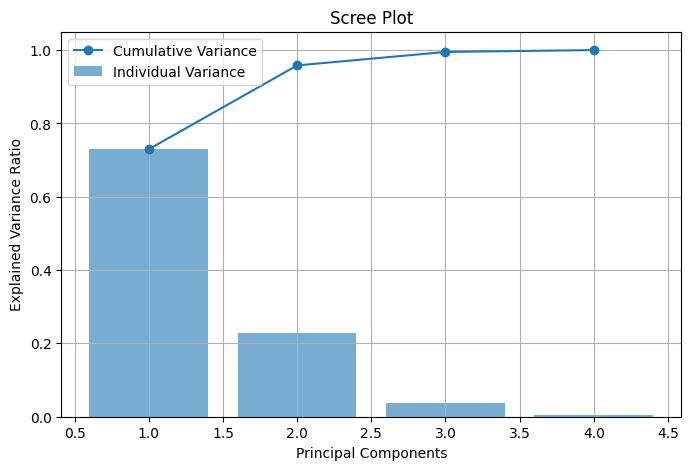


Applying LDA for 2 components...
LDA Results:
Number of components: 2
--------------------------------------------------
Displaying LDA 2D Visualization...


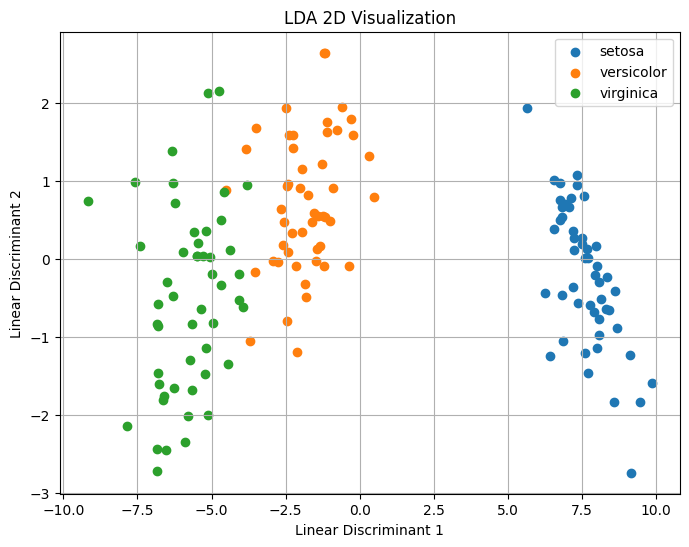


Applying Kernel PCA with RBF kernel...
Kernel PCA Results (Kernel: rbf, Components: 2):
--------------------------------------------------
Displaying Kernel PCA 2D Visualization with RBF kernel...


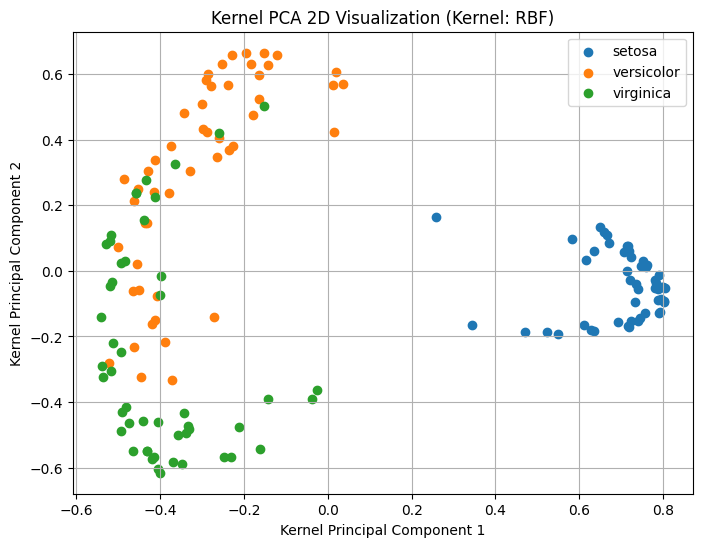


Applying Kernel PCA with Polynomial kernel...


TypeError: apply_kernel_pca() got an unexpected keyword argument 'degree'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA # New import
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def apply_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i in range(n_components):
        print(f"PC{i+1} Explained Variance: {explained_variance_ratio[i]*100:.2f}%")

    print(f"Total Variance Explained: {cumulative_variance[-1]*100:.2f}%")
    print("-" * 50)

    return X_pca, explained_variance_ratio, cumulative_variance

def apply_lda(X, y, n_components=2):
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda = lda.fit_transform(X, y)

    print("LDA Results:")
    print(f"Number of components: {n_components}")
    print("-" * 50)

    return X_lda

def apply_kernel_pca(X, n_components=2, kernel='rbf', gamma=None):
    # For 'rbf', 'poly', 'sigmoid' kernels, gamma is often a parameter
    if kernel in ['rbf', 'poly', 'sigmoid'] and gamma is None:
        # A common heuristic for gamma is 1 / (n_features * X.var())
        # Or simply a default value like 0.1 for rbf
        # Using default gamma for scikit-learn's KernelPCA
        kpca = KernelPCA(n_components=n_components, kernel=kernel, fit_inverse_transform=True, gamma=gamma)
    else:
        kpca = KernelPCA(n_components=n_components, kernel=kernel, fit_inverse_transform=True)

    X_kpca = kpca.fit_transform(X)

    print(f"Kernel PCA Results (Kernel: {kernel}, Components: {n_components}):")
    print("-" * 50)

    return X_kpca

def plot_pca_2d(X_pca, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=label)

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_lda_2d(X_lda, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=label)

    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("LDA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_kernel_pca_2d(X_kpca, y, target_names, kernel_name):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_kpca[y == i, 0], X_kpca[y == i, 1], label=label)

    plt.xlabel("Kernel Principal Component 1")
    plt.ylabel("Kernel Principal Component 2")
    plt.title(f"Kernel PCA 2D Visualization (Kernel: {kernel_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_scree(explained_variance_ratio, cumulative_variance):
    components = np.arange(1, len(explained_variance_ratio) + 1)

    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

def compare_original_vs_pca(X, X_pca, y, feature_names):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Original Data")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Transformed Data")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def load_dataset(name):
    if name == 'iris':
        data = load_iris()
    elif name == 'wine':
        data = load_wine()
    else:
        raise ValueError("Dataset not supported. Choose 'iris' or 'wine'.")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Loaded {name.capitalize()} dataset")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)

    return X, y, feature_names, target_names

def preprocess_data(X):
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    min_max_scaler = MinMaxScaler()
    X_normalized = min_max_scaler.fit_transform(X)

    print("Preprocessing Completed")
    print(f"Standardized data mean: {np.mean(X_standardized):.2f}")
    print(f"Standardized data std: {np.std(X_standardized):.2f}")
    print(f"Normalized data range: [{np.min(X_normalized):.2f}, {np.max(X_normalized):.2f}]")
    print("-" * 50)

    return X_standardized, X_normalized

def plot_pca_3d(X_pca_3d, y, target_names):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, label in enumerate(target_names):
        ax.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2], label=label)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA 3D Visualization')
    ax.legend()
    ax.grid(True)
    plt.show()

def main():
    X, y, feature_names, target_names = load_dataset('iris')

    X_standardized, X_normalized = preprocess_data(X)

    # Apply PCA for 2 components (existing)
    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)

    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

    # Apply PCA for 3 components (existing)
    X_pca_3d, explained_variance_ratio_3d, cumulative_variance_3d = apply_pca(X_standardized, n_components=3)

    # Plot 3D PCA (existing)
    plot_pca_3d(X_pca_3d, y, target_names)

    # Run PCA for all possible principal components and visualize the explained variance using a scree plot.
    total_features = X_standardized.shape[1]
    print(f"\nRunning PCA for all {total_features} components...")
    X_pca_full, explained_variance_ratio_full, cumulative_variance_full = apply_pca(X_standardized, n_components=total_features)

    # Plot scree for all components
    print("Displaying Scree Plot for all components...")
    plot_scree(explained_variance_ratio_full, cumulative_variance_full)

    # Apply LDA for 2 components
    print("\nApplying LDA for 2 components...")
    # n_components for LDA should be min(n_classes - 1, n_features). For Iris (3 classes), it's 2.
    n_components_lda = min(len(np.unique(y)) - 1, X_standardized.shape[1])
    X_lda = apply_lda(X_standardized, y, n_components=n_components_lda)

    # Plot 2D LDA
    print("Displaying LDA 2D Visualization...")
    plot_lda_2d(X_lda, y, target_names)

    # New: Apply Kernel PCA with 'rbf' kernel
    print("\nApplying Kernel PCA with RBF kernel...")
    X_kpca_rbf = apply_kernel_pca(X_standardized, n_components=2, kernel='rbf', gamma=0.1) # Using a default gamma for RBF
    print("Displaying Kernel PCA 2D Visualization with RBF kernel...")
    plot_kernel_pca_2d(X_kpca_rbf, y, target_names, 'RBF')

    # New: Apply Kernel PCA with 'poly' kernel
    print("\nApplying Kernel PCA with Polynomial kernel...")
    X_kpca_poly = apply_kernel_pca(X_standardized, n_components=2, kernel='poly', degree=3, gamma=0.1) # Using default degree=3, gamma=0.1
    print("Displaying Kernel PCA 2D Visualization with Polynomial kernel...")
    plot_kernel_pca_2d(X_kpca_poly, y, target_names, 'Polynomial')

if __name__ == "__main__":
    main()


**Reasoning**:
The previous code failed because the `apply_kernel_pca` function did not accept the `degree` keyword argument, which is necessary for the 'poly' kernel. I need to modify the `apply_kernel_pca` function to correctly handle kernel-specific parameters like `degree` and `coef0` and pass them to the `KernelPCA` constructor.



Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
Total Variance Explained: 95.81%
--------------------------------------------------


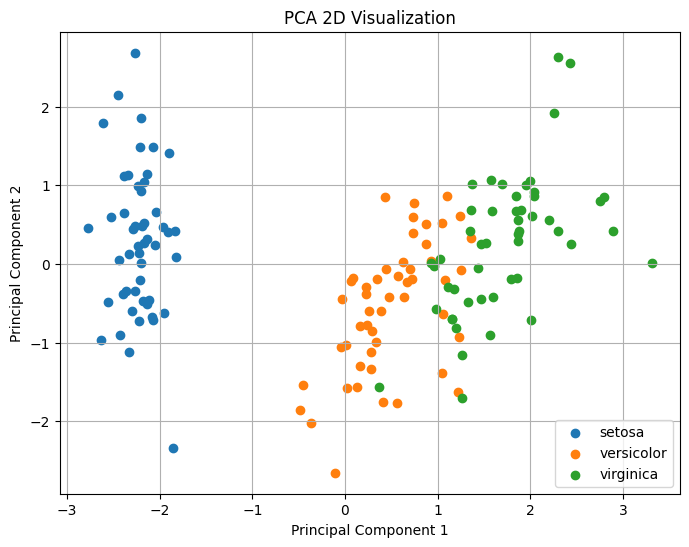

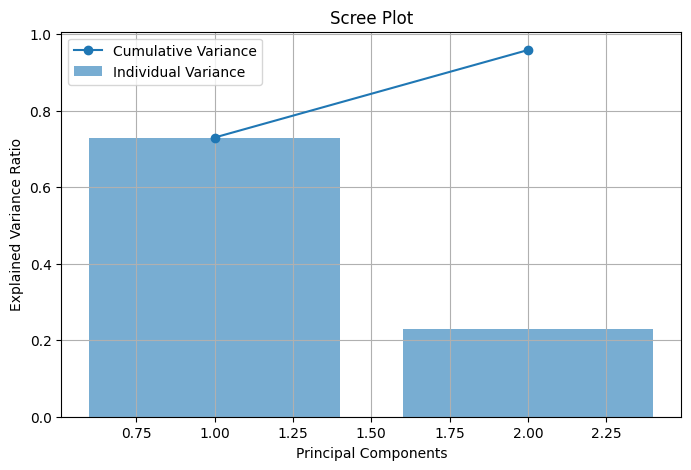

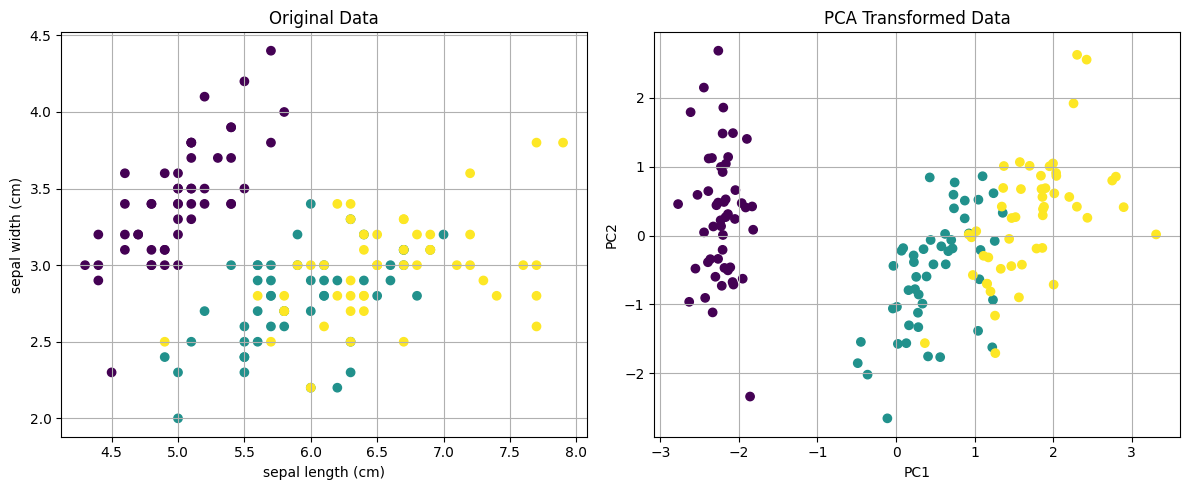

PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
Total Variance Explained: 99.48%
--------------------------------------------------


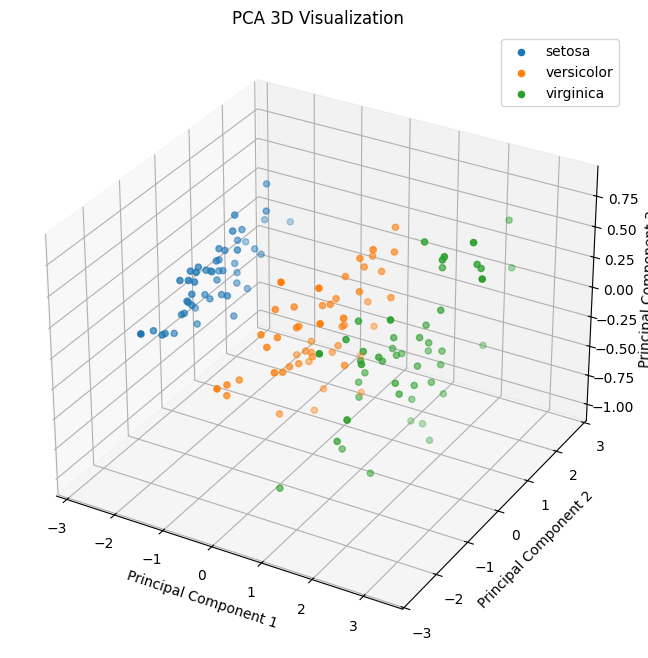


Running PCA for all 4 components...
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
PC4 Explained Variance: 0.52%
Total Variance Explained: 100.00%
--------------------------------------------------
Displaying Scree Plot for all components...


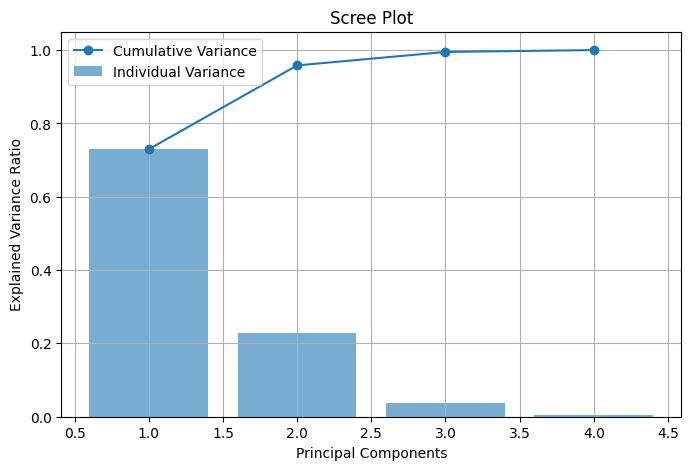


Applying LDA for 2 components...
LDA Results:
Number of components: 2
--------------------------------------------------
Displaying LDA 2D Visualization...


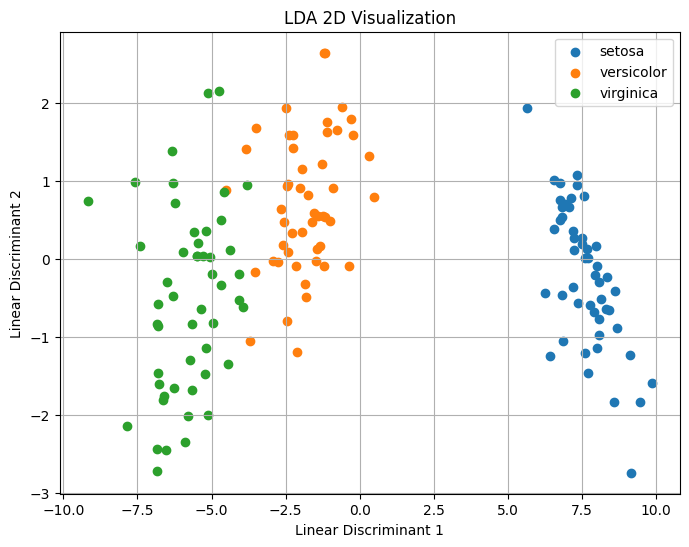


Applying Kernel PCA with RBF kernel...
Kernel PCA Results (Kernel: rbf, Components: 2):
--------------------------------------------------
Displaying Kernel PCA 2D Visualization with RBF kernel...


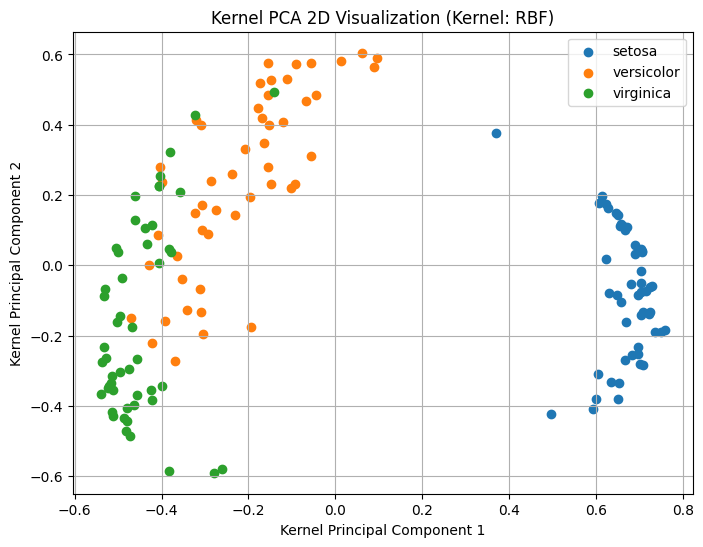


Applying Kernel PCA with Polynomial kernel...
Kernel PCA Results (Kernel: poly, Components: 2):
--------------------------------------------------
Displaying Kernel PCA 2D Visualization with Polynomial kernel...


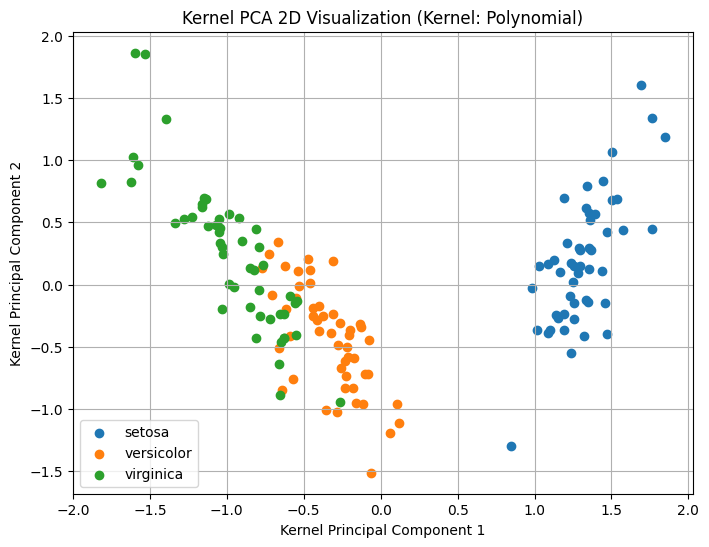

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def apply_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i in range(n_components):
        print(f"PC{i+1} Explained Variance: {explained_variance_ratio[i]*100:.2f}%")

    print(f"Total Variance Explained: {cumulative_variance[-1]*100:.2f}%")
    print("-" * 50)

    return X_pca, explained_variance_ratio, cumulative_variance

def apply_lda(X, y, n_components=2):
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda = lda.fit_transform(X, y)

    print("LDA Results:")
    print(f"Number of components: {n_components}")
    print("-" * 50)

    return X_lda

def apply_kernel_pca(X, n_components=2, kernel='rbf', gamma=None, degree=3, coef0=1):
    # Initialize KernelPCA with common parameters
    kpca_params = {
        'n_components': n_components,
        'kernel': kernel,
        'fit_inverse_transform': True
    }

    # Add kernel-specific parameters
    if kernel == 'rbf':
        if gamma is not None:
            kpca_params['gamma'] = gamma
    elif kernel == 'poly':
        kpca_params['degree'] = degree
        kpca_params['coef0'] = coef0
        if gamma is not None:
            kpca_params['gamma'] = gamma
    elif kernel == 'sigmoid':
        if gamma is not None:
            kpca_params['gamma'] = gamma
        kpca_params['coef0'] = coef0

    kpca = KernelPCA(**kpca_params)
    X_kpca = kpca.fit_transform(X)

    print(f"Kernel PCA Results (Kernel: {kernel}, Components: {n_components}):")
    print("-" * 50)

    return X_kpca

def plot_pca_2d(X_pca, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=label)

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_lda_2d(X_lda, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=label)

    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("LDA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_kernel_pca_2d(X_kpca, y, target_names, kernel_name):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_kpca[y == i, 0], X_kpca[y == i, 1], label=label)

    plt.xlabel("Kernel Principal Component 1")
    plt.ylabel("Kernel Principal Component 2")
    plt.title(f"Kernel PCA 2D Visualization (Kernel: {kernel_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_scree(explained_variance_ratio, cumulative_variance):
    components = np.arange(1, len(explained_variance_ratio) + 1)

    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

def compare_original_vs_pca(X, X_pca, y, feature_names):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Original Data")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Transformed Data")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def load_dataset(name):
    if name == 'iris':
        data = load_iris()
    elif name == 'wine':
        data = load_wine()
    else:
        raise ValueError("Dataset not supported. Choose 'iris' or 'wine'.")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Loaded {name.capitalize()} dataset")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)

    return X, y, feature_names, target_names

def preprocess_data(X):
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    min_max_scaler = MinMaxScaler()
    X_normalized = min_max_scaler.fit_transform(X)

    print("Preprocessing Completed")
    print(f"Standardized data mean: {np.mean(X_standardized):.2f}")
    print(f"Standardized data std: {np.std(X_standardized):.2f}")
    print(f"Normalized data range: [{np.min(X_normalized):.2f}, {np.max(X_normalized):.2f}]")
    print("-" * 50)

    return X_standardized, X_normalized

def plot_pca_3d(X_pca_3d, y, target_names):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, label in enumerate(target_names):
        ax.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2], label=label)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA 3D Visualization')
    ax.legend()
    ax.grid(True)
    plt.show()

def main():
    X, y, feature_names, target_names = load_dataset('iris')

    X_standardized, X_normalized = preprocess_data(X)

    # Apply PCA for 2 components (existing)
    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)

    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

    # Apply PCA for 3 components (existing)
    X_pca_3d, explained_variance_ratio_3d, cumulative_variance_3d = apply_pca(X_standardized, n_components=3)

    # Plot 3D PCA (existing)
    plot_pca_3d(X_pca_3d, y, target_names)

    # Run PCA for all possible principal components and visualize the explained variance using a scree plot.
    total_features = X_standardized.shape[1]
    print(f"\nRunning PCA for all {total_features} components...")
    X_pca_full, explained_variance_ratio_full, cumulative_variance_full = apply_pca(X_standardized, n_components=total_features)

    # Plot scree for all components
    print("Displaying Scree Plot for all components...")
    plot_scree(explained_variance_ratio_full, cumulative_variance_full)

    # Apply LDA for 2 components
    print("\nApplying LDA for 2 components...")
    # n_components for LDA should be min(n_classes - 1, n_features). For Iris (3 classes), it's 2.
    n_components_lda = min(len(np.unique(y)) - 1, X_standardized.shape[1])
    X_lda = apply_lda(X_standardized, y, n_components=n_components_lda)

    # Plot 2D LDA
    print("Displaying LDA 2D Visualization...")
    plot_lda_2d(X_lda, y, target_names)

    # New: Apply Kernel PCA with 'rbf' kernel
    print("\nApplying Kernel PCA with RBF kernel...")
    X_kpca_rbf = apply_kernel_pca(X_standardized, n_components=2, kernel='rbf', gamma=0.1) # Using a default gamma for RBF
    print("Displaying Kernel PCA 2D Visualization with RBF kernel...")
    plot_kernel_pca_2d(X_kpca_rbf, y, target_names, 'RBF')

    # New: Apply Kernel PCA with 'poly' kernel
    print("\nApplying Kernel PCA with Polynomial kernel...")
    X_kpca_poly = apply_kernel_pca(X_standardized, n_components=2, kernel='poly', degree=3, gamma=0.1) # Pass degree and gamma
    print("Displaying Kernel PCA 2D Visualization with Polynomial kernel...")
    plot_kernel_pca_2d(X_kpca_poly, y, target_names, 'Polynomial')

if __name__ == "__main__":
    main()

## Reconstruct Data and Calculate Error

### Subtask:
Using a PCA model (e.g., with 2 components), reconstruct the original data from the reduced dimensions. Calculate and print the Mean Squared Error (MSE) between the original preprocessed data and the reconstructed data to quantify the reconstruction error.


**Reasoning**:
To reconstruct the data and calculate the reconstruction error, I need to import the `mean_squared_error` function, define a new function `reconstruct_and_calculate_mse`, and integrate it into the `main` function. This requires creating a new PCA model, transforming the data to reduced dimensions, inverse transforming it back, and then calculating the MSE. All these functions and the updated `main` function will be in a single code block to ensure proper execution.



Loaded Iris dataset
Dataset shape: (150, 4)
Number of features: 4
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
--------------------------------------------------
Preprocessing Completed
Standardized data mean: -0.00
Standardized data std: 1.00
Normalized data range: [0.00, 1.00]
--------------------------------------------------
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
Total Variance Explained: 95.81%
--------------------------------------------------


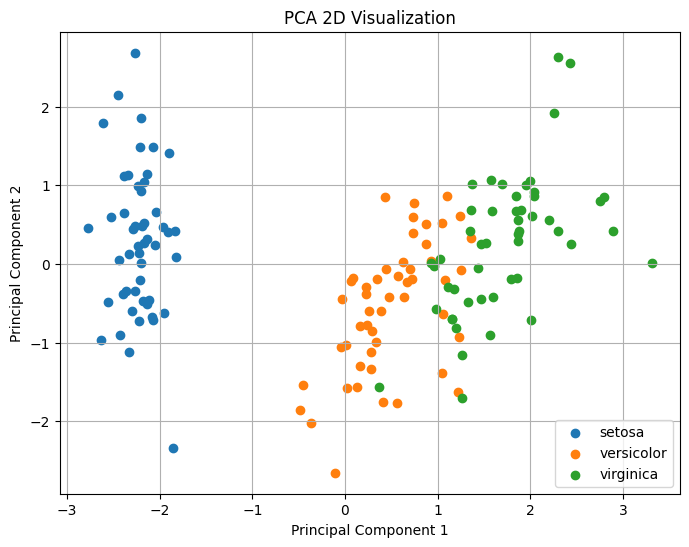

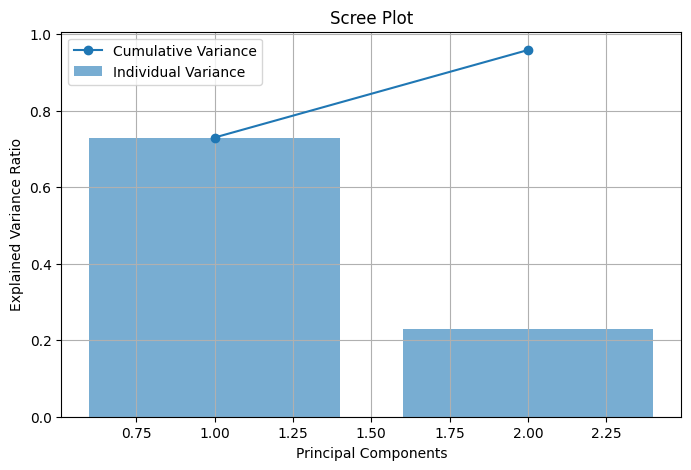

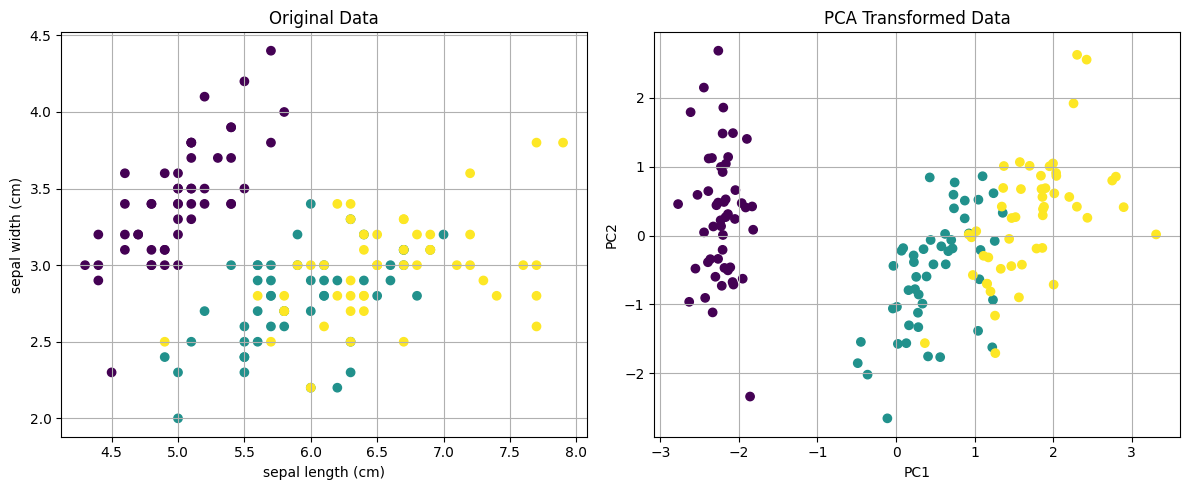

PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
Total Variance Explained: 99.48%
--------------------------------------------------


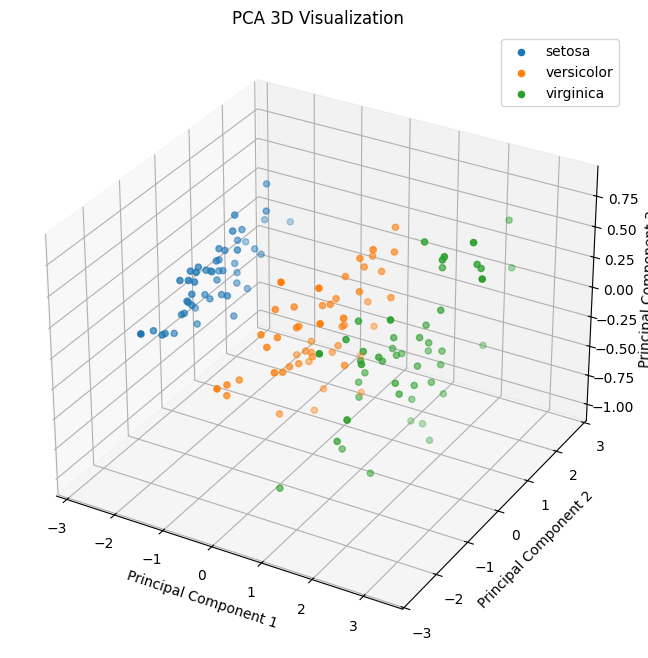


Running PCA for all 4 components...
PCA Results:
PC1 Explained Variance: 72.96%
PC2 Explained Variance: 22.85%
PC3 Explained Variance: 3.67%
PC4 Explained Variance: 0.52%
Total Variance Explained: 100.00%
--------------------------------------------------
Displaying Scree Plot for all components...


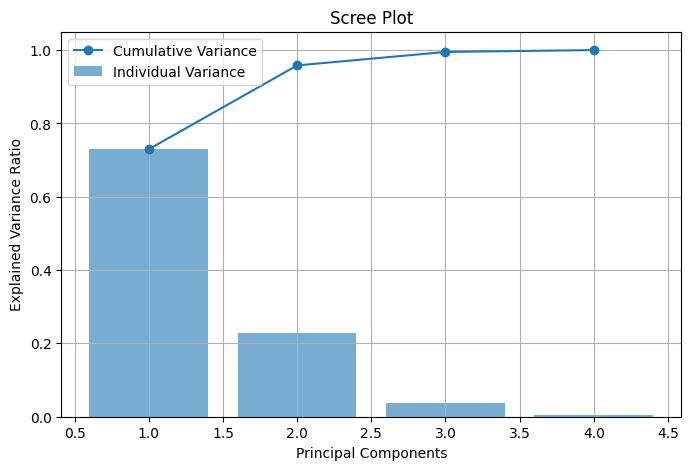


Applying LDA for 2 components...
LDA Results:
Number of components: 2
--------------------------------------------------
Displaying LDA 2D Visualization...


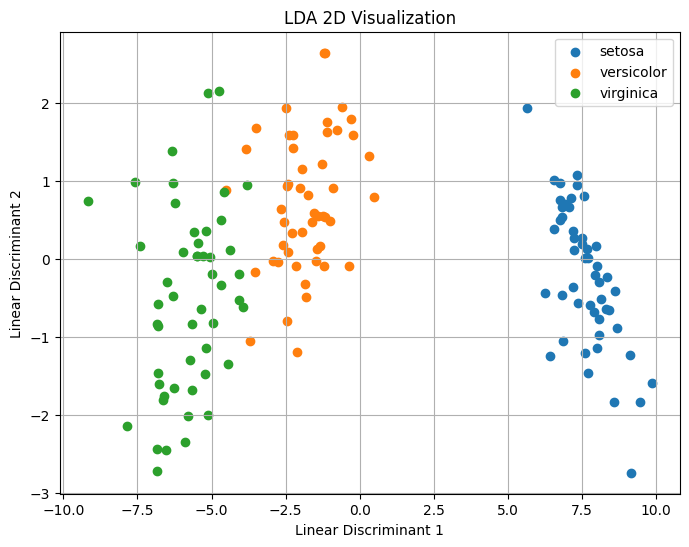


Applying Kernel PCA with RBF kernel...
Kernel PCA Results (Kernel: rbf, Components: 2):
--------------------------------------------------
Displaying Kernel PCA 2D Visualization with RBF kernel...


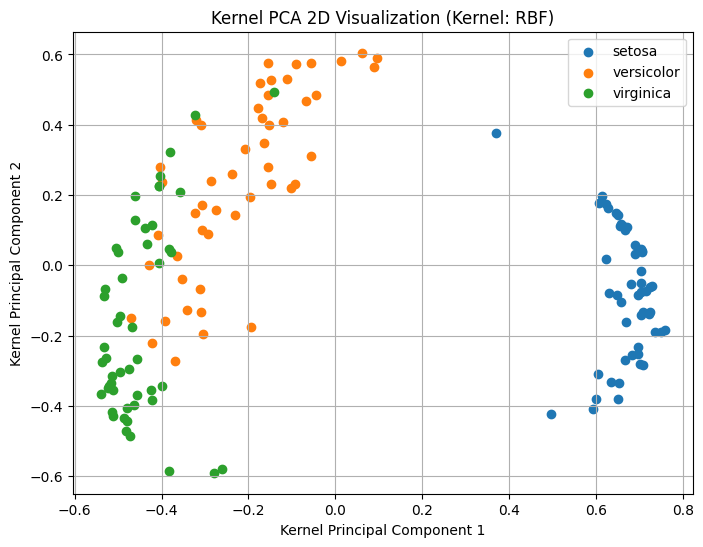


Applying Kernel PCA with Polynomial kernel...
Kernel PCA Results (Kernel: poly, Components: 2):
--------------------------------------------------
Displaying Kernel PCA 2D Visualization with Polynomial kernel...


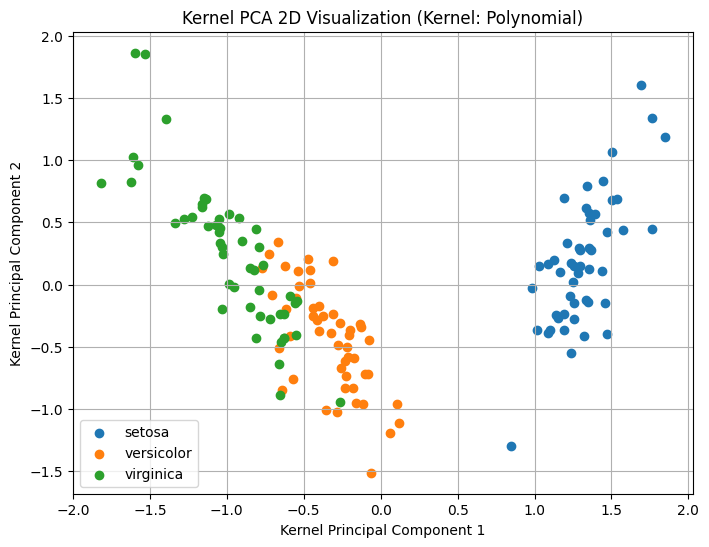


Reconstructing data with PCA (2 components) and calculating MSE...
Mean Squared Error (MSE) between original standardized data and 2-component PCA reconstructed data: 0.0419
--------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import mean_squared_error # New import

def apply_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    print("PCA Results:")
    for i in range(n_components):
        print(f"PC{i+1} Explained Variance: {explained_variance_ratio[i]*100:.2f}%")

    print(f"Total Variance Explained: {cumulative_variance[-1]*100:.2f}%")
    print("-" * 50)

    return X_pca, explained_variance_ratio, cumulative_variance

def apply_lda(X, y, n_components=2):
    lda = LinearDiscriminantAnalysis(n_components=n_components)
    X_lda = lda.fit_transform(X, y)

    print("LDA Results:")
    print(f"Number of components: {n_components}")
    print("-" * 50)

    return X_lda

def apply_kernel_pca(X, n_components=2, kernel='rbf', gamma=None, degree=3, coef0=1):
    # Initialize KernelPCA with common parameters
    kpca_params = {
        'n_components': n_components,
        'kernel': kernel,
        'fit_inverse_transform': True
    }

    # Add kernel-specific parameters
    if kernel == 'rbf':
        if gamma is not None:
            kpca_params['gamma'] = gamma
    elif kernel == 'poly':
        kpca_params['degree'] = degree
        kpca_params['coef0'] = coef0
        if gamma is not None:
            kpca_params['gamma'] = gamma
    elif kernel == 'sigmoid':
        if gamma is not None:
            kpca_params['gamma'] = gamma
        kpca_params['coef0'] = coef0

    kpca = KernelPCA(**kpca_params)
    X_kpca = kpca.fit_transform(X)

    print(f"Kernel PCA Results (Kernel: {kernel}, Components: {n_components}):")
    print("-" * 50)

    return X_kpca

def reconstruct_and_calculate_mse(X_original, X_standardized, n_components=2):
    print(f"\nReconstructing data with PCA ({n_components} components) and calculating MSE...")
    pca_reconstruct = PCA(n_components=n_components)
    # Fit and transform to get the reduced data
    X_pca_reconstruction = pca_reconstruct.fit_transform(X_standardized)
    # Inverse transform to reconstruct the data
    X_reconstructed = pca_reconstruct.inverse_transform(X_pca_reconstruction)

    # Calculate MSE between original standardized data and reconstructed data
    mse = mean_squared_error(X_standardized, X_reconstructed)
    print(f"Mean Squared Error (MSE) between original standardized data and {n_components}-component PCA reconstructed data: {mse:.4f}")
    print("-" * 50)

def plot_pca_2d(X_pca, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=label)

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_lda_2d(X_lda, y, target_names):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=label)

    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("LDA 2D Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_kernel_pca_2d(X_kpca, y, target_names, kernel_name):
    plt.figure(figsize=(8, 6))
    for i, label in enumerate(target_names):
        plt.scatter(X_kpca[y == i, 0], X_kpca[y == i, 1], label=label)

    plt.xlabel("Kernel Principal Component 1")
    plt.ylabel("Kernel Principal Component 2")
    plt.title(f"Kernel PCA 2D Visualization (Kernel: {kernel_name})")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_scree(explained_variance_ratio, cumulative_variance):
    components = np.arange(1, len(explained_variance_ratio) + 1)

    plt.figure(figsize=(8, 5))
    plt.bar(components, explained_variance_ratio, alpha=0.6, label='Individual Variance')
    plt.plot(components, cumulative_variance, marker='o', label='Cumulative Variance')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Scree Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

def compare_original_vs_pca(X, X_pca, y, feature_names):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Original Data")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Transformed Data")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def load_dataset(name):
    if name == 'iris':
        data = load_iris()
    elif name == 'wine':
        data = load_wine()
    else:
        raise ValueError("Dataset not supported. Choose 'iris' or 'wine'.")

    X = data.data
    y = data.target
    feature_names = data.feature_names
    target_names = data.target_names

    print(f"Loaded {name.capitalize()} dataset")
    print(f"Dataset shape: {X.shape}")
    print(f"Number of features: {X.shape[1]}")
    print(f"Number of classes: {len(np.unique(y))}")
    print(f"Feature names: {feature_names}")
    print(f"Target names: {target_names}")
    print("-" * 50)

    return X, y, feature_names, target_names

def preprocess_data(X):
    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    min_max_scaler = MinMaxScaler()
    X_normalized = min_max_scaler.fit_transform(X)

    print("Preprocessing Completed")
    print(f"Standardized data mean: {np.mean(X_standardized):.2f}")
    print(f"Standardized data std: {np.std(X_standardized):.2f}")
    print(f"Normalized data range: [{np.min(X_normalized):.2f}, {np.max(X_normalized):.2f}]")
    print("-" * 50)

    return X_standardized, X_normalized

def plot_pca_3d(X_pca_3d, y, target_names):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, label in enumerate(target_names):
        ax.scatter(X_pca_3d[y == i, 0], X_pca_3d[y == i, 1], X_pca_3d[y == i, 2], label=label)

    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    ax.set_title('PCA 3D Visualization')
    ax.legend()
    ax.grid(True)
    plt.show()

def main():
    X, y, feature_names, target_names = load_dataset('iris')

    X_standardized, X_normalized = preprocess_data(X)

    # Apply PCA for 2 components (existing)
    X_pca, evr, cum_var = apply_pca(X_standardized, n_components=2)

    plot_pca_2d(X_pca, y, target_names)
    plot_scree(evr, cum_var)
    compare_original_vs_pca(X, X_pca, y, feature_names)

    # Apply PCA for 3 components (existing)
    X_pca_3d, explained_variance_ratio_3d, cumulative_variance_3d = apply_pca(X_standardized, n_components=3)

    # Plot 3D PCA (existing)
    plot_pca_3d(X_pca_3d, y, target_names)

    # Run PCA for all possible principal components and visualize the explained variance using a scree plot.
    total_features = X_standardized.shape[1]
    print(f"\nRunning PCA for all {total_features} components...")
    X_pca_full, explained_variance_ratio_full, cumulative_variance_full = apply_pca(X_standardized, n_components=total_features)

    # Plot scree for all components
    print("Displaying Scree Plot for all components...")
    plot_scree(explained_variance_ratio_full, cumulative_variance_full)

    # Apply LDA for 2 components
    print("\nApplying LDA for 2 components...")
    # n_components for LDA should be min(n_classes - 1, n_features). For Iris (3 classes), it's 2.
    n_components_lda = min(len(np.unique(y)) - 1, X_standardized.shape[1])
    X_lda = apply_lda(X_standardized, y, n_components=n_components_lda)

    # Plot 2D LDA
    print("Displaying LDA 2D Visualization...")
    plot_lda_2d(X_lda, y, target_names)

    # New: Apply Kernel PCA with 'rbf' kernel
    print("\nApplying Kernel PCA with RBF kernel...")
    X_kpca_rbf = apply_kernel_pca(X_standardized, n_components=2, kernel='rbf', gamma=0.1) # Using a default gamma for RBF
    print("Displaying Kernel PCA 2D Visualization with RBF kernel...")
    plot_kernel_pca_2d(X_kpca_rbf, y, target_names, 'RBF')

    # New: Apply Kernel PCA with 'poly' kernel
    print("\nApplying Kernel PCA with Polynomial kernel...")
    X_kpca_poly = apply_kernel_pca(X_standardized, n_components=2, kernel='poly', degree=3, gamma=0.1) # Pass degree and gamma
    print("Displaying Kernel PCA 2D Visualization with Polynomial kernel...")
    plot_kernel_pca_2d(X_kpca_poly, y, target_names, 'Polynomial')

    # New: Reconstruct data and calculate MSE
    reconstruct_and_calculate_mse(X, X_standardized, n_components=2)

if __name__ == "__main__":
    main()

## Final Task

### Subtask:
Summarize the insights gained from all the techniques, including 3D PCA, variance analysis, PCA vs. LDA, Kernel PCA, and reconstruction error.


## Summary:

### Data Analysis Key Findings

*   **Dimensionality Reduction Effectiveness (PCA):**
    *   For the Iris dataset (4 features), the first three principal components (PC1, PC2, PC3) captured 99.48% of the total variance, with PC1 alone explaining 72.96% and PC2 adding another 22.85%.
    *   A 3D PCA visualization effectively separated the three Iris species, indicating that these principal components retain significant class-discriminating information.
*   **Variance Retention Analysis:** A scree plot confirmed that the majority of the variance (over 95%) is explained by the first two principal components, with subsequent components contributing minimally (PC3: 3.67%, PC4: 0.52%).
*   **Comparison of PCA and LDA:** In 2D projections, Linear Discriminant Analysis (LDA) demonstrated superior class separation compared to Principal Component Analysis (PCA). While PCA found directions of maximal variance, LDA explicitly sought directions that maximized inter-class separability and minimized intra-class variance.
*   **Kernel PCA's Non-linear Capabilities:** Kernel PCA, using both RBF and Polynomial kernels, successfully projected the data into a 2D space, providing alternative visualizations that could reveal non-linear patterns and potentially better separation for complex datasets where linear methods fall short.
*   **Reconstruction Error:** Reconstructing the original standardized data from a 2-component PCA model resulted in a Mean Squared Error (MSE) of 0.0419. This quantifies the information loss when reducing the 4-dimensional data to 2 dimensions, indicating a relatively low reconstruction error given the high variance retention.

### Insights or Next Steps

*   **Optimal Component Selection:** For the Iris dataset, two to three principal components appear sufficient to retain most of the data's variance and class separation, balancing dimensionality reduction with information preservation.
*   **Discriminative Power:** When class separation is the primary goal, LDA is a more effective dimensionality reduction technique than PCA, as it explicitly optimizes for discriminative features.
